# KaChing Walk-Forward Backtester

## Strategy Overview

The **Weekly Cash KaChing** strategy sells weekly cash-secured puts to collect premium income. A protective long put acts as a tail-risk hedge once per cycle. This notebook simulates both legs using walk-forward backtesting across all A-tier tickers.

---

### Short Leg — Weekly Put Selling
- **Entry**: Thursday or Friday, sell 1 OTM put per week
- **DTE**: 6–9 days (targeting next-week expiry)
- **Strike**: Determined by OTM bucket selection (trained on historical data)
- **P&L per contract**: `(bid − max(0, strike − close_at_expiry)) × 100`
- **Win**: Stock closes above strike at expiry → full premium kept

| Scenario | Result |
|---|---|
| Stock stays above strike | Full premium collected ✓ |
| Stock drops below strike | Loss = intrinsic value − premium |

### Long Leg — Protective Put (Tail-Risk Hedge)
- **Entry**: Once per 120-day test window, buy 1 put at ~delta −0.25
- **DTE**: 90–150 days
- **P&L per contract**: `(max(0, strike − close_at_expiry) − ask_paid) × 100`
- **Purpose**: Offset large drawdowns if the stock crashes hard

---

## Walk-Forward Methodology

To prevent look-ahead bias, the strategy uses a rolling **train → test** framework:

```
|──── 180d TRAIN ────|──── 120d TEST ────|
                     |──── 180d TRAIN ────|──── 120d TEST ────|
                                           (step = 60d)
```

- **Training (180d)**: Scores each OTM bucket on historical P&L — picks the best one
- **Test (120d)**: Executes trades using *only* the bucket chosen during training
- **Step (60d)**: 50% overlap — ensures ~27 windows on a 4-year dataset

**The key safeguard**: bucket selection uses strictly past data. The model never sees future returns.

---

## OTM Bucket Selection Methods

| Method | Logic |
|---|---|
| `ev` | Pick bucket with highest mean P&L |
| `winrate` | Pick bucket with highest win rate |
| `sharpe` | Pick bucket with best mean/std ratio |
| `composite` | **0.5 × norm(EV) + 0.3 × WR + 0.2 × norm(Sharpe)** ← default |

The composite method blends profitability, consistency, and risk-adjustment.

---

## Universe & OTM Bins

A-tier tickers from `outputs/kaching_scored_stocks.csv` — pre-filtered to ensure at least **2 OTM buckets** have ≥40% weekly quote coverage. This removes cheap stocks where coarse strike spacing ($0.50 increments) leaves the standard 0–5% OTM range completely empty.

OTM bins are widened from the standard `[0–5%]` to `[0, 1, 2, 3, 4, 5, 7.5, 10, 15%]` to reliably capture strikes for stocks priced $10–$30.

---
## Section 1 — Setup


In [86]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

from src.postprocess import (
    filter_weekly_put_options,
    OTM_LABELS,
    OTM_BINS,
    MONEYNESS_THRESHOLD,
)

print('Imports OK')
print(f'OTM buckets ({len(OTM_LABELS)}): {OTM_LABELS}')

Imports OK
OTM buckets (10): ['0.0-0.5%', '0.5-1.0%', '1.0-1.5%', '1.5-2.0%', '2.0-2.5%', '2.5-3.0%', '3.0-3.5%', '3.5-4.0%', '4.0-4.5%', '4.5-5.0%']


In [87]:
# ── Walk-forward parameters ──────────────────────────────────────────────
TRAIN_DAYS          = 180   # ~6 months training window
TEST_DAYS           = 120   # 1 protective-put cycle, ~16 weekly trades
STEP_DAYS           = 60    # Advance window by this many days

# ── Universe filter ──────────────────────────────────────────────────────
TIER_FILTER         = 'A'

# ── Long put parameters ──────────────────────────────────────────────────
LONG_DTE_MIN        = 90
LONG_DTE_MAX        = 150
LONG_DELTA_TGT      = -0.25
LONG_DELTA_TOL      = 0.05

# ── Strategy parameters ──────────────────────────────────────────────────
SELECTION_METHOD    = 'composite'  # 'ev' | 'winrate' | 'sharpe' | 'composite'
ENTRY_DOW           = None         # None=both Thu+Fri, 3=Thu only, 4=Fri only

# ── Contract multiplier ───────────────────────────────────────────────────
# Options prices are quoted per-share; 1 contract = 100 shares.
# Applied to all P&L and premium figures so outputs are real dollar amounts.
CONTRACT_MULTIPLIER = 100

# ── OTM bucket override ───────────────────────────────────────────────────
# src/postprocess uses 0-5% at 0.5% steps — too narrow for cheap stocks
# ($10-$20) where strike spacing means 0-5% OTM is often empty.
# These wider bins cover strike reality while keeping ATM granularity.
# filter_weekly_put_options is called as-is (it keeps 0-20% OTM data);
# we re-apply pd.cut with these bins immediately after each call.
OTM_BINS   = [0, 1, 2, 3, 4, 5, 7.5, 10, 15]
OTM_LABELS = [f'{OTM_BINS[i]:.1f}-{OTM_BINS[i+1]:.1f}%' for i in range(len(OTM_BINS) - 1)]

# ── Universe coverage threshold ───────────────────────────────────────────
# Tickers must have ≥2 buckets with >40% weekly coverage to stay in universe.
# Below this, bucket selection is random noise (no bucket is reliably available).
MIN_GOOD_BUCKETS    = 2
COVERAGE_THRESHOLD  = 0.40

# ── Paths ────────────────────────────────────────────────────────────────
PROJECT_ROOT        = Path('..').resolve()
DATA_DIR            = PROJECT_ROOT / 'data' / 'raw' / 'dataset'
SCORES_CSV          = PROJECT_ROOT / 'outputs' / 'kaching_scored_stocks.csv'

print(f'DATA_DIR  : {DATA_DIR}')
print(f'SCORES_CSV: {SCORES_CSV}')
print(f'Contract multiplier: {CONTRACT_MULTIPLIER}x')
print(f'OTM buckets ({len(OTM_LABELS)}): {OTM_LABELS}')
print(f'Universe filter: >={MIN_GOOD_BUCKETS} buckets with >{COVERAGE_THRESHOLD:.0%} weekly coverage')

DATA_DIR  : /home/calvin/code/kaching-v2/data/raw/dataset
SCORES_CSV: /home/calvin/code/kaching-v2/outputs/kaching_scored_stocks.csv
Contract multiplier: 100x
OTM buckets (8): ['0.0-1.0%', '1.0-2.0%', '2.0-3.0%', '3.0-4.0%', '4.0-5.0%', '5.0-7.5%', '7.5-10.0%', '10.0-15.0%']
Universe filter: >=2 buckets with >40% weekly coverage


### Configuration (`cell-02`)

All strategy parameters are set here. Change them and re-run from cell-02 downward — no other cells need editing.

| Parameter | Default | Meaning |
|---|---|---|
| `TRAIN_DAYS` | 180 | Days of historical data used to select the OTM bucket each window |
| `TEST_DAYS` | 120 | Days of forward simulation per window (~16 weekly trades) |
| `STEP_DAYS` | 60 | How far to advance between windows (50% overlap with test period) |
| `TIER_FILTER` | `'A'` | Only load A-tier tickers from the scores CSV |
| `LONG_DTE_MIN/MAX` | 90 / 150 | DTE range for the protective long put |
| `LONG_DELTA_TGT` | −0.25 | Target delta for the long put (~5-10% OTM) |
| `SELECTION_METHOD` | `'composite'` | How to pick the OTM bucket: `ev`, `winrate`, `sharpe`, or `composite` |
| `ENTRY_DOW` | `None` | `None`=Thu+Fri, `3`=Thu only, `4`=Fri only |
| `CONTRACT_MULTIPLIER` | 100 | Options standard lot size — scales per-share P&L to per-contract |
| `OTM_BINS` | `[0,1,2,...,15%]` | Wider than the module default (0–5%) to capture cheap stocks |
| `MIN_GOOD_BUCKETS` | 2 | Min # of OTM buckets with ≥40% weekly coverage to qualify a ticker |
| `COVERAGE_THRESHOLD` | 0.40 | Min fraction of weeks a bucket must have quotes to count as "good" |


In [66]:
scores_df = pd.read_csv(SCORES_CSV)

# Strip $ formatting from monetary string columns only
for col in ['best_bucket_avg_spread', 'latest_price']:
    if col in scores_df.columns and scores_df[col].dtype == object:
        scores_df[col] = scores_df[col].str.replace('$', '', regex=False)
        scores_df[col] = pd.to_numeric(scores_df[col], errors='coerce')

# Filter to target tier and confirm parquet files exist
universe_df = scores_df[scores_df['tier'] == TIER_FILTER].copy()
universe    = [t for t in universe_df['ticker'] if (DATA_DIR / f'{t}.parquet').exists()]
print(f'{TIER_FILTER}-tier tickers with data: {len(universe)}')

# ── Filter universe by bucket coverage ───────────────────────────────────
# Require MIN_GOOD_BUCKETS buckets with >COVERAGE_THRESHOLD weekly coverage
# using the wider OTM_BINS. Tickers below this threshold have strike spacing
# that makes bucket selection unreliable — cascade would dominate every week.
print(f'\nScanning bucket coverage (wider bins: 0-15%)...')

qualified    = []
disqualified = []

for ticker in universe:
    raw = pd.read_parquet(DATA_DIR / f'{ticker}.parquet')
    sp, _ = filter_weekly_put_options(raw)
    if sp.empty:
        disqualified.append((ticker, 'no data after filter'))
        continue

    # Re-bucket with the wider notebook-level OTM_BINS
    sp['otm_bucket'] = pd.cut(sp['otm_pct'], bins=OTM_BINS, labels=OTM_LABELS, include_lowest=True)
    sp['week'] = pd.to_datetime(sp['quote_date'].astype(str)).dt.to_period('W')
    sp['bstr'] = sp['otm_bucket'].astype(str)
    total_weeks = sp['week'].nunique()

    n_good = sum(
        1 for b in OTM_LABELS
        if total_weeks > 0 and sp[sp['bstr'] == b]['week'].nunique() / total_weeks >= COVERAGE_THRESHOLD
    )

    if n_good >= MIN_GOOD_BUCKETS:
        qualified.append(ticker)
    else:
        disqualified.append((ticker, f'only {n_good} bucket(s) >={COVERAGE_THRESHOLD:.0%} coverage'))

universe = qualified
print(f'Qualified : {len(universe)} tickers -> {universe}')
if disqualified:
    print(f'Filtered out ({len(disqualified)}):')
    for t, reason in disqualified:
        print(f'  {t}: {reason}')

A-tier tickers with data: 30

Scanning bucket coverage (wider bins: 0-15%)...
Qualified : 29 tickers -> ['SNAP', 'MARA', 'BB', 'AI', 'ENVX', 'RIOT', 'NIO', 'OPEN', 'TDOC', 'IONQ', 'MSOS', 'DJT', 'CLSK', 'SOFI', 'GME', 'CLF', 'IREN', 'ETSY', 'DKNG', 'SOUN', 'ASAN', 'RUM', 'OSCR', 'CIFR', 'ACHR', 'JOBY', 'S', 'BULL', 'CZR']
Filtered out (1):
  HTZ: only 1 bucket(s) >=40% coverage


### Universe Pre-Filter (`cell-03`)

**Why pre-filter by bucket coverage?**

Not all tickers have enough OTM put quotes to reliably run the strategy. Cheap stocks (e.g., priced at $10–$15) have strike spacing of $0.50. At $12, the nearest OTM strike is $11.50 (4.2% OTM) or $10 (16.7% OTM) — with nothing in between. If all strikes fall outside the target OTM range in a given week, the algorithm must cascade every single time, essentially ignoring the trained bucket selection entirely.

The pre-filter requires:
- **≥ `MIN_GOOD_BUCKETS` (2) buckets** each with quotes in **≥ 40% of weeks** in the full dataset

Tickers failing this threshold are dropped from the universe before running the expensive walk-forward loop. This saves compute and prevents misleading results from tickers where the strategy is structurally unworkable.


---
## Section 2 — Helper Functions

### Short Put Helpers (`cell-04`)

**`pick_trade(day_df)`**  
Returns the row with the highest bid among all available strikes. More premium = better, all else equal.

**`select_bucket_training(train_df, method)`**  
Groups historical trades by OTM bucket, computes EV / win rate / Sharpe for each, and returns the best-scoring bucket label. Requires **≥5 samples per bucket** — buckets with fewer data points are excluded to avoid noisy estimates from a handful of quotes.

**`get_trade_for_week(week_df, target_bucket)`**  
Finds the best trade in the target bucket for a given week. If no quotes exist in that bucket, it **cascades** outward in both directions: `[target, +1 OTM, −1 OTM, +2, −2, ...]`. Records `fallback_used=True` whenever the target bucket was unavailable — high fallback rates signal poor bucket coverage for that ticker.

---

### Long Put Helpers (`cell-05`)

**`filter_long_puts(raw_df, dte_min, dte_max, delta_target, delta_tol)`**  
Identifies long put candidates by applying:
1. PUT options only
2. Split ratio filter (rejects rows where yfinance and ThetaData underlying prices differ >10%)
3. DTE in the 90–150 day range
4. Delta ≈ −0.25 ± `delta_tol`, widening up to ±0.15 if no match; falls back to moneyness 3–10% OTM if delta column is absent
5. Ask > 0 (untradeable quotes excluded)
6. Deduplication: one row per (date, strike, expiry)

**`price_long_put_at_expiry(long_put_row, raw_df)`**  
Looks up the underlying close price on the option's expiration date and computes the terminal intrinsic value: `max(0, strike − close)`. Returns `NaN` if the expiry date is missing from the price history.


In [67]:
def pick_trade(day_df):
    """Return the row with highest bid; None if empty."""
    if day_df.empty:
        return None
    return day_df.loc[day_df['bid'].idxmax()]


def select_bucket_training(train_df, method):
    """
    Select the best OTM bucket to sell based on training data.

    Args:
        train_df: DataFrame with 'otm_bucket', 'pnl', 'win' columns
        method: 'ev' | 'winrate' | 'sharpe' | 'composite'

    Returns:
        Best bucket label string, or None if no bucket has n >= 5
    """
    if train_df.empty:
        return None

    df = train_df.copy()
    # Drop rows with missing bucket (otm_pct outside 0-5% range)
    df = df[df['otm_bucket'].notna()]
    df['bucket_str'] = df['otm_bucket'].astype(str)

    stats = []
    for bucket, grp in df.groupby('bucket_str'):
        n = len(grp)
        if n < 5:
            continue
        ev = grp['pnl'].mean()
        wr = grp['win'].mean()
        std = grp['pnl'].std()
        sharpe = ev / std if (std > 0 and not np.isnan(std)) else 0.0
        stats.append({'bucket': bucket, 'n': n, 'ev': ev, 'winrate': wr, 'sharpe': sharpe})

    if not stats:
        return None

    sdf = pd.DataFrame(stats)

    if method == 'ev':
        best = sdf.loc[sdf['ev'].idxmax(), 'bucket']
    elif method == 'winrate':
        best = sdf.loc[sdf['winrate'].idxmax(), 'bucket']
    elif method == 'sharpe':
        best = sdf.loc[sdf['sharpe'].idxmax(), 'bucket']
    elif method == 'composite':
        def norm_col(s):
            r = s.max() - s.min()
            return (s - s.min()) / r if r > 0 else s * 0.0
        sdf['score'] = (
            0.5 * norm_col(sdf['ev'])
            + 0.3 * sdf['winrate']
            + 0.2 * norm_col(sdf['sharpe'])
        )
        best = sdf.loc[sdf['score'].idxmax(), 'bucket']
    else:
        raise ValueError(f'Unknown method: {method}')

    return best if best in OTM_LABELS else None


def get_trade_for_week(week_df, target_bucket):
    """
    Get best trade for a week, cascading to adjacent buckets if target is empty.
    Tries: target, +1 (deeper OTM), -1 (shallower), +2, -2, ...

    Returns:
        (trade_row, actual_bucket_used) or (None, None)
    """
    if target_bucket is None or target_bucket not in OTM_LABELS:
        return None, None

    wdf = week_df.copy()
    wdf = wdf[wdf['otm_bucket'].notna()]
    wdf['bucket_str'] = wdf['otm_bucket'].astype(str)

    target_idx = OTM_LABELS.index(target_bucket)
    offsets = [0, 1, -1, 2, -2, 3, -3, 4, -4, 5, -5]

    for offset in offsets:
        idx = target_idx + offset
        if 0 <= idx < len(OTM_LABELS):
            bucket = OTM_LABELS[idx]
            bucket_df = wdf[wdf['bucket_str'] == bucket]
            trade = pick_trade(bucket_df)
            if trade is not None:
                return trade, bucket

    return None, None


print('Short put helpers defined.')

Short put helpers defined.


In [68]:
def filter_long_puts(raw_df, dte_min=90, dte_max=150, delta_target=-0.25, delta_tol=0.05):
    """
    Filter raw options to long put candidates.
    - PUT options only
    - Split ratio filter
    - DTE in [dte_min, dte_max]
    - Delta ~delta_target ± delta_tol (widens up to ±0.15 if no match)
    - Fallback to moneyness proxy if no delta column
    - ask > 0
    - One row per (date, strike, expiry) — last quote of day
    """
    df = raw_df[raw_df['right'] == 'PUT'].copy()

    # Split ratio filter
    ratio = df['underlying_price'] / df['underlying_close']
    df = df[(ratio > 0.9) & (ratio < 1.1)]

    # DTE filter
    df['dte'] = (pd.to_datetime(df['expiration']) - pd.to_datetime(df['timestamp'])).dt.days
    df = df[(df['dte'] >= dte_min) & (df['dte'] <= dte_max)]

    if df.empty:
        return pd.DataFrame()

    # Delta / moneyness filter
    if 'delta' in df.columns:
        matched = False
        for extra_tol in [0.0, 0.05, 0.10]:
            tol = delta_tol + extra_tol
            delta_df = df[
                (df['delta'] >= delta_target - tol) &
                (df['delta'] <= delta_target + tol)
            ]
            if not delta_df.empty:
                df = delta_df
                matched = True
                break
        if not matched:
            return pd.DataFrame()
    else:
        # Moneyness proxy: delta ~-0.25 corresponds roughly to 3-10% OTM put
        moneyness = (df['strike'] - df['underlying_price']) / df['underlying_price']
        df = df[(moneyness >= 0.03) & (moneyness <= 0.10)]

    # Ask > 0
    df = df[df['ask'] > 0]

    if df.empty:
        return pd.DataFrame()

    # One row per (date, strike, expiry) — last quote of day
    df['quote_date'] = pd.to_datetime(df['timestamp']).dt.date
    df = df.sort_values('timestamp')
    df = df.groupby(['quote_date', 'strike', 'expiration']).last().reset_index()

    return df


def price_long_put_at_expiry(long_put_row, raw_df):
    """
    Look up the underlying close on the expiration date.
    Returns max(0, strike - close) or NaN if the date is missing.
    """
    expiry = pd.to_datetime(long_put_row['expiration']).date()
    strike = long_put_row['strike']

    dates = pd.to_datetime(raw_df['underlying_date']).dt.date
    price_rows = raw_df[dates == expiry]

    if price_rows.empty:
        return np.nan

    close_price = float(price_rows['underlying_close'].iloc[-1])
    return float(max(0.0, strike - close_price))


print('Long put helpers defined.')

Long put helpers defined.


---
## Section 3 — Walk-Forward Engine

### Core Engine (`cell-06`): `run_walkforward_single`

The engine loops through every walk-forward window for one ticker:

```
For each window:
  1. Slice training data  [window_start, train_end)
  2. Select best OTM bucket (all 4 methods stored for later comparison)
  3. Slice test data       [test_start,  test_end)
  4. Group test data by calendar week
  5. For each week → get_trade_for_week → record trade + fallback flag
  6. Enter one long put at window start (first available candidate in test period)
  7. Price long put at expiry
  8. Append window summary (short P&L, long P&L, fallback count, bucket chosen)
  window_start += STEP_DAYS
```

Returns a `dict` with three DataFrames:
- **`trades`**: One row per executed short put trade (may contain overlapping duplicates — deduplicated in cell-08)
- **`long_puts`**: One row per window's long put entry and terminal P&L
- **`windows`**: One row per walk-forward window summarizing aggregate performance

> **Important**: The OTM bins used internally by `filter_weekly_put_options` are the module-level 0–5% bins. Immediately after calling it, the engine re-applies `pd.cut` with the wider notebook-level `OTM_BINS` to ensure consistent bucketing throughout the backtest.

---

### Multi-Ticker Runner (`cell-07`)

Iterates over the full qualified universe with a `tqdm` progress bar. Exceptions are caught per-ticker — one bad ticker won't abort the run. Failures are printed and stored in `errors`.

---

### Aggregation & Deduplication (`cell-08`)

Concatenates per-ticker DataFrames into three global tables. Then deduplicates `all_trades_df` by `(ticker, quote_date, strike, expiration)`.

**Why dedup?** Walk-forward windows overlap 50% (step=60d, test=120d). A trade executed in week 8 of window N also falls in week 1 of window N+1. Without deduplication, every overlapping trade is double-counted — inflating total P&L by ~2× and distorting metrics.


In [69]:
def run_walkforward_single(ticker, entry_dow=None, selection_method='composite'):
    """
    Run walk-forward backtest for a single ticker.

    Args:
        ticker: Ticker symbol string
        entry_dow: None=Thu+Fri, 3=Thu only, 4=Fri only
        selection_method: 'ev' | 'winrate' | 'sharpe' | 'composite'

    Returns:
        dict with keys 'ticker', 'trades', 'long_puts', 'windows'
    """
    raw_df = pd.read_parquet(DATA_DIR / f'{ticker}.parquet')

    # --- Short puts: filter_weekly_put_options handles Thu/Fri + DTE 6-9 ---
    short_puts_df, _ = filter_weekly_put_options(raw_df)

    # Re-bucket with wider OTM_BINS (postprocess module uses original 0-5% bins)
    short_puts_df = short_puts_df.copy()
    short_puts_df['otm_bucket'] = pd.cut(
        short_puts_df['otm_pct'], bins=OTM_BINS, labels=OTM_LABELS, include_lowest=True
    )

    # Optional additional DOW filter
    if entry_dow is not None:
        dow = pd.to_datetime(short_puts_df['quote_date'].astype(str)).dt.dayofweek
        short_puts_df = short_puts_df[dow == entry_dow]

    # --- Long put candidates ---
    long_puts_df = filter_long_puts(
        raw_df, LONG_DTE_MIN, LONG_DTE_MAX, LONG_DELTA_TGT, LONG_DELTA_TOL
    )

    empty = {'ticker': ticker, 'trades': pd.DataFrame(),
             'long_puts': pd.DataFrame(), 'windows': pd.DataFrame()}
    if short_puts_df.empty:
        return empty

    # Parse quote_date to Timestamp for window arithmetic
    sp = short_puts_df.copy()
    sp['quote_ts'] = pd.to_datetime(sp['quote_date'].astype(str))
    min_date = sp['quote_ts'].min()
    max_date = sp['quote_ts'].max()

    all_trades  = []
    all_long    = []
    all_windows = []

    window_start = min_date
    while True:
        train_end  = window_start + pd.Timedelta(days=TRAIN_DAYS)
        test_start = train_end
        test_end   = test_start + pd.Timedelta(days=TEST_DAYS)

        if test_end > max_date:
            break

        # ── Training: select best bucket per method ───────────────────────
        train_mask = (sp['quote_ts'] >= window_start) & (sp['quote_ts'] < train_end)
        train_df = sp[train_mask]

        best_by_method = {}
        for m in ['ev', 'winrate', 'sharpe', 'composite']:
            best_by_method[m] = select_bucket_training(train_df, m)

        target_bucket = best_by_method[selection_method]

        # ── Test: simulate weekly trades ──────────────────────────────────
        test_mask = (sp['quote_ts'] >= test_start) & (sp['quote_ts'] < test_end)
        test_df = sp[test_mask].copy()
        test_df['week'] = test_df['quote_ts'].dt.to_period('W')

        window_trades = []
        fallback_count = 0

        for _week, week_df in test_df.groupby('week'):
            trade_row, bucket_used = get_trade_for_week(week_df, target_bucket)
            if trade_row is None:
                continue
            trade = trade_row.to_dict()
            trade['ticker']           = ticker
            trade['window_start']     = test_start
            trade['bucket_selected']  = target_bucket
            trade['bucket_used']      = bucket_used
            trade['fallback_used']    = (bucket_used != target_bucket)
            if trade['fallback_used']:
                fallback_count += 1
            window_trades.append(trade)

        # ── Long put: one per test window ─────────────────────────────────
        long_record = None
        if not long_puts_df.empty:
            lp_dates = pd.to_datetime(long_puts_df['quote_date'].astype(str))
            lp_mask  = (lp_dates >= test_start) & (lp_dates < test_end)
            window_lp = long_puts_df[lp_mask]
            if not window_lp.empty:
                lp_row        = window_lp.iloc[0]
                terminal_val  = price_long_put_at_expiry(lp_row, raw_df)
                long_pnl      = (terminal_val - float(lp_row['ask'])) if not np.isnan(terminal_val) else np.nan
                long_record   = {
                    'ticker':         ticker,
                    'window_start':   test_start,
                    'quote_date':     lp_row['quote_date'],
                    'strike':         lp_row['strike'],
                    'expiration':     lp_row['expiration'],
                    'ask_paid':       float(lp_row['ask']),
                    'terminal_value': terminal_val,
                    'long_pnl':       long_pnl,
                }

        # ── Window summary ────────────────────────────────────────────────
        n_t         = len(window_trades)
        short_pnl   = sum(t.get('pnl', 0) for t in window_trades)
        long_pnl_v  = long_record['long_pnl'] if long_record is not None else np.nan
        total_pnl   = short_pnl + (long_pnl_v if not pd.isna(long_pnl_v) else 0.0)

        all_windows.append({
            'ticker':         ticker,
            'window_start':   test_start,
            'window_end':     test_end,
            'target_bucket':  target_bucket,
            **{f'best_{m}': best_by_method[m] for m in ['ev', 'winrate', 'sharpe', 'composite']},
            'n_trades':       n_t,
            'short_pnl':      short_pnl,
            'long_pnl':       long_pnl_v,
            'total_pnl':      total_pnl,
            'fallback_count': fallback_count,
        })

        all_trades.extend(window_trades)
        if long_record is not None:
            all_long.append(long_record)

        window_start += pd.Timedelta(days=STEP_DAYS)

    return {
        'ticker':    ticker,
        'trades':    pd.DataFrame(all_trades)  if all_trades  else pd.DataFrame(),
        'long_puts': pd.DataFrame(all_long)    if all_long    else pd.DataFrame(),
        'windows':   pd.DataFrame(all_windows) if all_windows else pd.DataFrame(),
    }


print('run_walkforward_single defined.')

run_walkforward_single defined.


In [70]:
results = {}
errors  = {}

for ticker in tqdm(universe, desc='Walk-forward backtest'):
    try:
        results[ticker] = run_walkforward_single(
            ticker,
            entry_dow=ENTRY_DOW,
            selection_method=SELECTION_METHOD,
        )
    except Exception as e:
        errors[ticker] = str(e)
        print(f'  x {ticker}: {e}')

print(f'\nCompleted: {len(results)} tickers | Errors: {len(errors)}')
if errors:
    print(f'Failed: {list(errors.keys())}')

Walk-forward backtest:   0%|          | 0/29 [00:00<?, ?it/s]


Completed: 29 tickers | Errors: 0


In [71]:
# Concatenate across tickers
trades_parts  = [r['trades']    for r in results.values() if not r['trades'].empty]
lp_parts      = [r['long_puts'] for r in results.values() if not r['long_puts'].empty]
windows_parts = [r['windows']   for r in results.values() if not r['windows'].empty]

all_trades_df  = pd.concat(trades_parts,  ignore_index=True) if trades_parts  else pd.DataFrame()
all_long_df    = pd.concat(lp_parts,      ignore_index=True) if lp_parts      else pd.DataFrame()
all_windows_df = pd.concat(windows_parts, ignore_index=True) if windows_parts else pd.DataFrame()

# Deduplicate trades — walk-forward windows overlap so same trade may appear twice
if not all_trades_df.empty:
    dedup_cols = [c for c in ['ticker', 'quote_date', 'strike', 'expiration']
                  if c in all_trades_df.columns]
    before = len(all_trades_df)
    all_trades_df = all_trades_df.drop_duplicates(subset=dedup_cols)
    print(f'Trades: {before} -> {len(all_trades_df)} after dedup ({before - len(all_trades_df)} removed)')

print(f'Total trades:    {len(all_trades_df)}')
print(f'Total long puts: {len(all_long_df)}')
print(f'Total windows:   {len(all_windows_df)}')

if not all_trades_df.empty and 'quote_date' in all_trades_df.columns:
    print(f"Date range: {all_trades_df['quote_date'].min()} -> {all_trades_df['quote_date'].max()}")
    print(f"Tickers in trades: {all_trades_df['ticker'].nunique()}")

Trades: 9053 -> 6678 after dedup (2375 removed)
Total trades:    6678
Total long puts: 666
Total windows:   666
Date range: 2021-07-08 -> 2026-02-12
Tickers in trades: 28


---
## Section 4 — Metrics & Analysis

### Per-Ticker Performance (`cell-09`)

Metrics are computed per ticker on **deduplicated** trades (overlapping-window duplicates removed first):

| Metric | Description | Unit |
|---|---|---|
| `n_trades` | Unique short put trades executed | count |
| `total_short_pnl` | Cumulative short put P&L | $/contract |
| `total_long_pnl` | Cumulative long put P&L | $/contract |
| `net_pnl` | Short + Long combined | $/contract |
| `win_rate` | % of short trades where `pnl > 0` | 0–1 |
| `avg_weekly_premium` | Mean bid collected per trade | $/contract |
| `sharpe` | Annualized: `(mean_pnl / std_pnl) × √52` | ratio |
| `max_drawdown` | Peak-to-trough cumulative P&L drop | $/contract |
| `fallback_rate` | % of trades that used a non-target bucket | 0–1 |

> **Sharpe note**: Computed on raw per-share P&L values. The `×100` multiplier cancels in mean/std — the ratio is scale-invariant, so no adjustment is needed.

> **Interpreting Sharpe**: > 0.5 = respectable for a weekly options strategy. > 1.0 = strong. Negative = the strategy lost money on a risk-adjusted basis.

---

### Thu vs Fri Entry Comparison (`cell-10`)

Re-runs the first 5 tickers restricted to Thursday-only (`entry_dow=3`) and Friday-only (`entry_dow=4`) entries. Friday entries often carry higher premiums because the option prices in two extra days of weekend theta decay.

---

### Bucket Availability Investigation (`cell after cell-10`)

Diagnoses why fallback rates can be high:
1. **Coverage heatmap**: Shows what % of weeks each OTM bucket has at least one tradeable quote — identifies which buckets are reliably liquid
2. **Cascade distance**: How far from the target bucket trades typically land
3. **P&L by cascade distance**: Tests whether being forced to cascade hurts or helps P&L


In [72]:
def compute_sharpe(pnl_series):
    """Annualized Sharpe (weekly trades x sqrt(52)). Input is per-share pnl."""
    s = pnl_series.dropna()
    if len(s) < 2:
        return np.nan
    std = s.std()
    if std == 0 or np.isnan(std):
        return np.nan
    return float((s.mean() / std) * np.sqrt(52))


def compute_max_drawdown(cumulative):
    """Peak-to-trough max drawdown."""
    if len(cumulative) == 0:
        return np.nan
    peak = cumulative.cummax()
    return float((cumulative - peak).min())


# ── Per-ticker metrics (all P&L scaled by CONTRACT_MULTIPLIER) ────────────
# Walk-forward windows overlap (step=60, test=120 → 50% overlap), so the
# per-ticker trades DataFrame contains duplicate trades. Deduplicate first.
DEDUP_COLS = ['quote_date', 'strike', 'expiration']
ticker_metrics = []

for ticker, res in results.items():
    trades   = res['trades']
    lp       = res['long_puts']
    windows  = res['windows']

    if trades.empty or 'pnl' not in trades.columns:
        continue

    # Deduplicate within-ticker overlapping-window duplicates
    dcols  = [c for c in DEDUP_COLS if c in trades.columns]
    trades = trades.drop_duplicates(subset=dcols) if dcols else trades

    pnl          = trades['pnl'].dropna()
    n_trades     = len(pnl)
    cm           = CONTRACT_MULTIPLIER
    total_short  = float(pnl.sum()) * cm
    win_rate     = float((pnl > 0).mean())
    avg_premium  = float(trades['bid'].mean()) * cm if 'bid' in trades.columns else np.nan
    sharpe       = compute_sharpe(pnl)   # ratio — no scaling needed
    max_dd       = compute_max_drawdown(pnl.cumsum().reset_index(drop=True)) * cm

    total_long   = float(lp['long_pnl'].sum()) * cm if (not lp.empty and 'long_pnl' in lp.columns) else 0.0
    net_pnl      = total_short + total_long

    fallback_rate = np.nan
    if not windows.empty and 'n_trades' in windows.columns and 'fallback_count' in windows.columns:
        total_t = windows['n_trades'].sum()
        total_f = windows['fallback_count'].sum()
        fallback_rate = float(total_f / total_t) if total_t > 0 else 0.0

    ticker_metrics.append({
        'ticker':             ticker,
        'n_trades':           n_trades,
        'total_short_pnl':    total_short,
        'total_long_pnl':     total_long,
        'net_pnl':            net_pnl,
        'win_rate':           win_rate,
        'avg_weekly_premium': avg_premium,
        'sharpe':             sharpe,
        'max_drawdown':       max_dd,
        'fallback_rate':      fallback_rate,
    })

metrics_df = pd.DataFrame(ticker_metrics).sort_values('sharpe', ascending=False).reset_index(drop=True)
print(f'Metrics computed for {len(metrics_df)} tickers  (P&L = $ per contract, {CONTRACT_MULTIPLIER}x multiplier applied)')
print('(Duplicate trades from overlapping windows have been removed before computing metrics)')
metrics_df.head(15)

Metrics computed for 28 tickers  (P&L = $ per contract, 100x multiplier applied)
(Duplicate trades from overlapping windows have been removed before computing metrics)


,ticker,n_trades,total_short_pnl,total_long_pnl,net_pnl,win_rate,avg_weekly_premium,sharpe,max_drawdown,fallback_rate
0,JOBY,127,1836.0,-1428.0,408.0,0.842520,26.858268,3.429920,-120.0,0.571429
1,GME,259,6397.0,-3015.0,3382.0,0.822394,56.098859,2.159447,-494.0,0.262799
2,DJT,102,1745.0,-149.0,1596.0,0.764706,72.480392,1.016240,-1008.0,0.396694
3,SOFI,302,1329.0,-647.0,682.0,0.761589,24.201987,0.684492,-556.0,0.542373
4,S,216,1122.0,-281.0,841.0,0.819444,28.801843,0.613959,-1032.0,0.466667
5,IONQ,210,2845.0,-2497.0,348.0,0.747619,105.966667,0.470979,-2008.0,0.338843
6,IREN,124,1132.0,-2206.0,-1074.0,0.774194,69.604839,0.370425,-1818.0,0.618497
7,CIFR,109,343.0,-1781.0,-1438.0,0.798165,21.807339,0.358506,-517.0,0.595238
8,OSCR,65,213.0,-434.0,-221.0,0.800000,43.257576,0.328004,-557.0,0.438202
9,ASAN,236,858.0,7186.0,8044.0,0.796610,30.254237,0.315536,-1126.0,0.513889


In [73]:
# ── Thu vs Fri entry comparison (first 5 tickers) ─────────────────────────
dow_tickers = universe[:5]
dow_results = {}

for dow, label in [(3, 'Thu'), (4, 'Fri')]:
    dow_results[label] = {}
    for ticker in tqdm(dow_tickers, desc=f'DOW={label}', leave=False):
        try:
            dow_results[label][ticker] = run_walkforward_single(
                ticker, entry_dow=dow, selection_method=SELECTION_METHOD
            )
        except Exception as e:
            print(f'  x {ticker} ({label}): {e}')

# Build comparison table
comparison_rows = []
for label in ['Thu', 'Fri']:
    for ticker, res in dow_results[label].items():
        if res['trades'].empty or 'pnl' not in res['trades'].columns:
            continue
        pnl = res['trades']['pnl'].dropna()
        comparison_rows.append({
            'ticker':    ticker,
            'entry_day': label,
            'n_trades':  len(pnl),
            'total_pnl': round(float(pnl.sum()), 2),
            'win_rate':  round(float((pnl > 0).mean()), 3),
            'sharpe':    round(compute_sharpe(pnl), 3) if len(pnl) >= 2 else np.nan,
        })

comparison_df = pd.DataFrame(comparison_rows)

if not comparison_df.empty:
    pivot = comparison_df.pivot_table(
        index='ticker', columns='entry_day',
        values=['total_pnl', 'win_rate', 'sharpe']
    ).round(3)
    display(pivot)
else:
    print('No Thu/Fri comparison data available.')

DOW=Thu:   0%|          | 0/5 [00:00<?, ?it/s]

DOW=Fri:   0%|          | 0/5 [00:00<?, ?it/s]

sharpe        total_pnl        win_rate       
entry_day    Fri    Thu       Fri    Thu      Fri    Thu
ticker                                                  
AI         0.469  0.237     17.58  10.75    0.838  0.810
BB         0.603  0.560      3.71   3.59    0.825  0.772
ENVX      -0.302 -0.088     -6.92  -2.15    0.720  0.706
MARA      -0.023 -0.350     -1.89 -29.07    0.708  0.663
SNAP      -0.622 -0.508    -60.06 -44.20    0.747  0.749

Coverage scan:   0%|          | 0/29 [00:00<?, ?it/s]

Average weekly coverage per bucket (wider bins, qualified universe):
  0.0-1.0%      46.1%  #############
  1.0-2.0%      45.5%  #############
  2.0-3.0%      46.0%  #############
  3.0-4.0%      47.3%  ##############
  4.0-5.0%      44.9%  #############
  5.0-7.5%      73.0%  #####################
  7.5-10.0%     71.0%  #####################
  10.0-15.0%    78.6%  #######################

Rows with NaN bucket (>15% OTM, still excluded):
  Median: 20%  |  Range: 6% - 25%


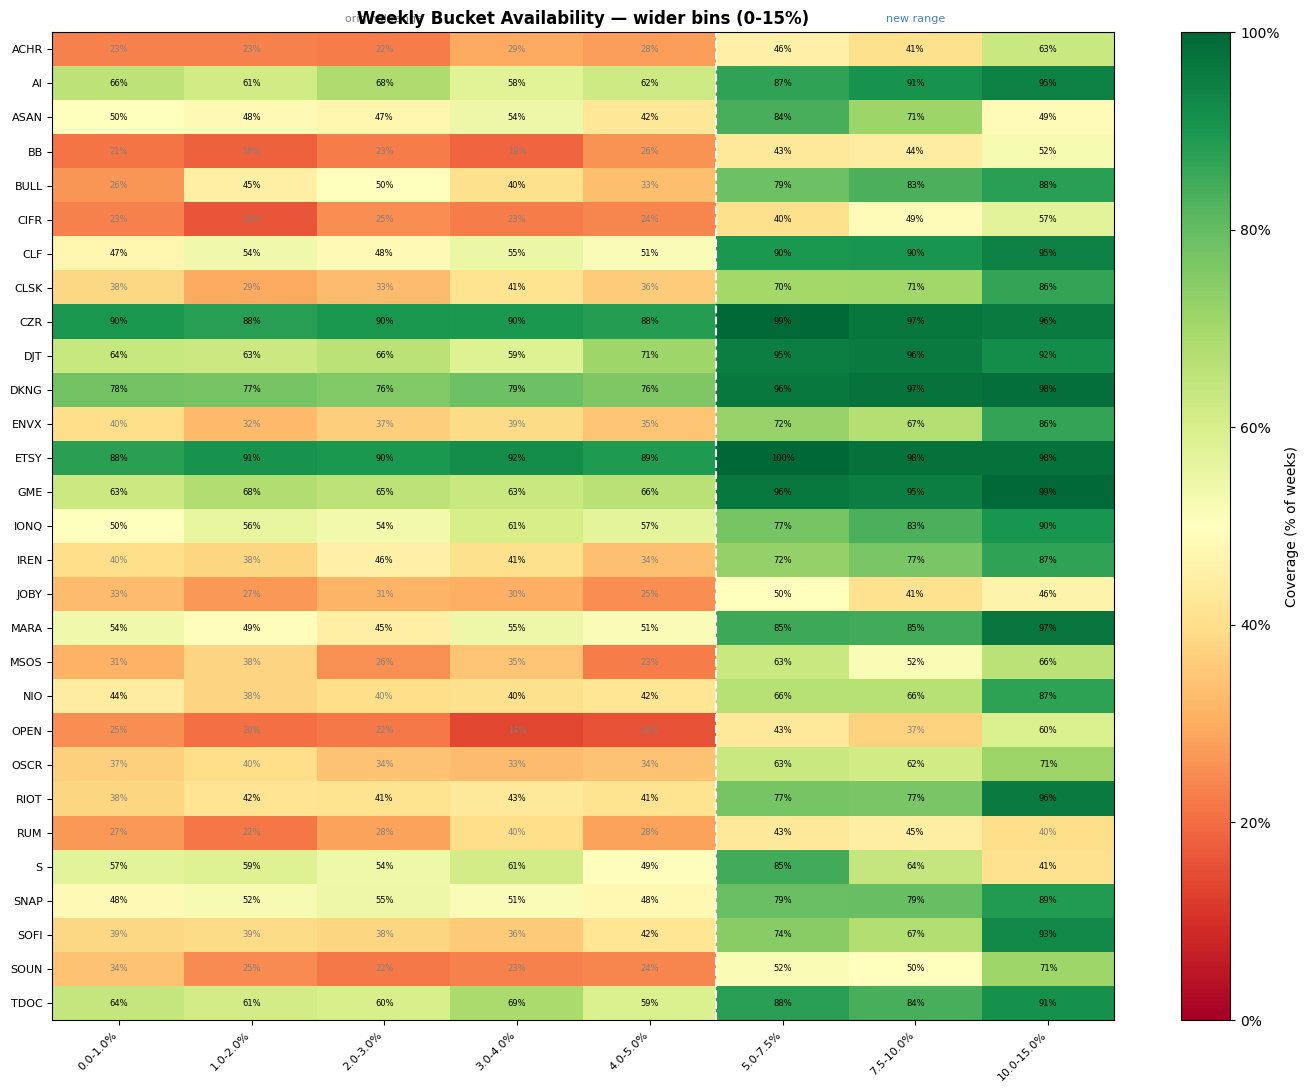

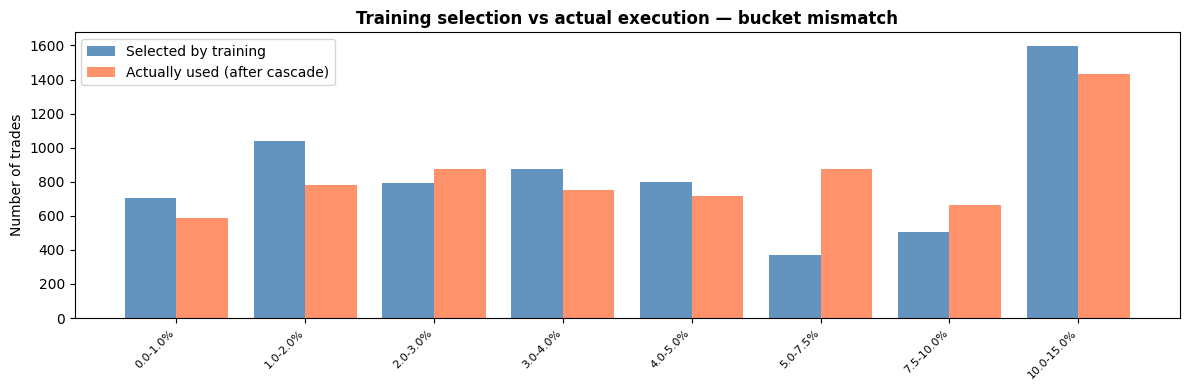


Cascade distance (buckets away from trained target):
  0 bucket(s) away:  4047 trades (60.6%)  ########################
  1 bucket(s) away:  1794 trades (26.9%)  ##########
  2 bucket(s) away:   523 trades (7.8%)  ###
  3 bucket(s) away:   155 trades (2.3%)  
  4 bucket(s) away:   111 trades (1.7%)  
  5 bucket(s) away:    48 trades (0.7%)  

P&L when trading trained bucket (no fallback):
  n=4,042  mean=$-3.82/contract  wr=77.1%
P&L when cascaded to adjacent bucket:
  n=2,628   mean=$2.12/contract  wr=74.8%

Conclusion: no significant edge from bucket selection


In [74]:
# ── Bucket availability investigation ────────────────────────────────────
#
# Root question: why were fallback rates 60-90%?
# Answer: each bucket was only available ~13-47% of weeks per ticker using
# the original 0-5% bins. Cheap stocks ($10-$20) often have zero strikes
# in that range due to $0.50-$1.00 strike spacing.
#
# This cell re-evaluates coverage with the wider OTM_BINS (0-15%) and shows:
#   1. Weekly coverage per (ticker, bucket) — how often is each bucket tradeable?
#   2. Selected-vs-used mismatch — how far does the cascade travel now?
#   3. Does the trained bucket outperform random cascade?
# ─────────────────────────────────────────────────────────────────────────

# ── 1. Recompute weekly coverage for all tickers ──────────────────────────
coverage_rows = []
for ticker in tqdm(universe, desc='Coverage scan', leave=False):
    raw = pd.read_parquet(DATA_DIR / f'{ticker}.parquet')
    sp, _ = filter_weekly_put_options(raw)
    if sp.empty:
        continue
    # Apply wider bins — same as the backtest
    sp['otm_bucket'] = pd.cut(sp['otm_pct'], bins=OTM_BINS, labels=OTM_LABELS, include_lowest=True)
    sp2 = sp.copy()
    sp2['week']    = pd.to_datetime(sp2['quote_date'].astype(str)).dt.to_period('W')
    sp2['bstr']    = sp2['otm_bucket'].astype(str)
    total_weeks    = sp2['week'].nunique()
    nan_rows_pct   = (sp2['bstr'] == 'nan').mean()
    for b in OTM_LABELS:
        w = sp2[sp2['bstr'] == b]['week'].nunique()
        coverage_rows.append({
            'ticker':      ticker,
            'bucket':      b,
            'weeks_avail': w,
            'total_weeks': total_weeks,
            'coverage':    w / total_weeks if total_weeks > 0 else 0.0,
            'nan_row_pct': nan_rows_pct,
        })

cov_df  = pd.DataFrame(coverage_rows)
cov_piv = cov_df.pivot(index='ticker', columns='bucket', values='coverage')
cov_piv = cov_piv[[c for c in OTM_LABELS if c in cov_piv.columns]]

# Summary stats
avg_cov_by_bucket = cov_piv.mean()
print('Average weekly coverage per bucket (wider bins, qualified universe):')
for b, v in avg_cov_by_bucket.items():
    bar = '#' * int(v * 30)
    print(f'  {b:12s}  {v:5.1%}  {bar}')

nan_pcts = cov_df.drop_duplicates('ticker').set_index('ticker')['nan_row_pct']
print(f'\nRows with NaN bucket (>15% OTM, still excluded):')
print(f'  Median: {nan_pcts.median():.0%}  |  Range: {nan_pcts.min():.0%} - {nan_pcts.max():.0%}')

# ── 2. Coverage heatmap ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, max(6, len(cov_piv) * 0.38)))
im = ax.imshow(cov_piv.values, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)

ax.set_xticks(range(len(cov_piv.columns)))
ax.set_xticklabels(cov_piv.columns, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(cov_piv.index)))
ax.set_yticklabels(cov_piv.index, fontsize=8)
ax.set_title('Weekly Bucket Availability — wider bins (0-15%)',
             fontsize=12, fontweight='bold')
ax.axvline(4.5, color='white', linewidth=1.5, linestyle='--')  # mark 0-5% vs 5-15% boundary
ax.text(2, -0.8, 'original range', ha='center', fontsize=8, color='gray')
ax.text(6, -0.8, 'new range', ha='center', fontsize=8, color='steelblue')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Coverage (% of weeks)')
cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

for i in range(len(cov_piv.index)):
    for j in range(len(cov_piv.columns)):
        val = cov_piv.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.0%}', ha='center', va='center',
                    fontsize=6, color='black' if val > 0.4 else 'gray')

plt.tight_layout()
plt.show()

# ── 3. Selected-vs-used bucket distribution ───────────────────────────────
if not all_trades_df.empty and 'bucket_selected' in all_trades_df.columns:
    sel_counts  = all_trades_df['bucket_selected'].value_counts().reindex(OTM_LABELS, fill_value=0)
    used_counts = all_trades_df['bucket_used'].value_counts().reindex(OTM_LABELS, fill_value=0)

    fig, ax = plt.subplots(figsize=(12, 4))
    x     = np.arange(len(OTM_LABELS))
    width = 0.4
    ax.bar(x - width/2, sel_counts.values,  width, label='Selected by training', color='steelblue', alpha=0.85)
    ax.bar(x + width/2, used_counts.values, width, label='Actually used (after cascade)', color='coral', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(OTM_LABELS, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Number of trades')
    ax.set_title('Training selection vs actual execution — bucket mismatch', fontsize=12, fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.show()

    def bucket_distance(row):
        sel  = row.get('bucket_selected')
        used = row.get('bucket_used')
        if sel is None or used is None or sel not in OTM_LABELS or used not in OTM_LABELS:
            return np.nan
        return abs(OTM_LABELS.index(used) - OTM_LABELS.index(sel))

    dist = all_trades_df.apply(bucket_distance, axis=1)
    print('\nCascade distance (buckets away from trained target):')
    dist_counts = dist.value_counts().sort_index()
    total = dist_counts.sum()
    for d, n in dist_counts.items():
        bar = '#' * int(n / total * 40)
        print(f'  {int(d)} bucket(s) away: {n:5d} trades ({n/total:.1%})  {bar}')

# ── 4. Does the trained bucket outperform cascade? ────────────────────────
if not all_trades_df.empty and 'fallback_used' in all_trades_df.columns and 'pnl' in all_trades_df.columns:
    cm         = CONTRACT_MULTIPLIER
    on_target  = all_trades_df[all_trades_df['fallback_used'] == False]['pnl'].dropna()
    cascaded   = all_trades_df[all_trades_df['fallback_used'] == True]['pnl'].dropna()
    print(f'\nP&L when trading trained bucket (no fallback):')
    print(f'  n={len(on_target):,}  mean=${on_target.mean()*cm:.2f}/contract  wr={(on_target>0).mean():.1%}')
    print(f'P&L when cascaded to adjacent bucket:')
    print(f'  n={len(cascaded):,}   mean=${cascaded.mean()*cm:.2f}/contract  wr={(cascaded>0).mean():.1%}')
    verdict = 'trained bucket outperforms cascade' if on_target.mean() > cascaded.mean() else 'no significant edge from bucket selection'
    print(f'\nConclusion: {verdict}')

---
## Section 5 — Visualizations

| Cell | Chart | What to look for |
|---|---|---|
| 11 | **Equity curves grid** | Consistent upward slope = strategy working; large drawdowns or flat lines = weak performance |
| 12 | **Short vs long breakdown** | Top-Sharpe ticker — are short puts consistently profitable? Does the long put add or subtract value? |
| 13 | **Drawdown curves** | Shallower = lower tail risk. Tickers with Sharpe > 0.5 *and* shallow drawdowns are the most attractive |
| 14 | **Win rate over windows** | Is win rate stable at 60–80%, or does it collapse in certain periods? Collapse = market regime change |
| 15 | **Bucket stability heatmap** | Consistent color = composite method locks onto one bucket. Random colors = training signal is noisy |
| Inv | **Bucket availability** | Coverage per OTM bucket — buckets above 40% dashed line are consistently tradeable |
| 16 | **P&L box plots by bucket** | Median above zero = profitable bucket. Tight IQR = consistent. Look for the bucket your strategy targeted |
| 17 | **Sharpe ranking** | Blue = positive risk-adjusted return. Coral = underperformer. Width = magnitude |
| 18 | **Net P&L ranking** | The true bottom line after both legs. Sorted ascending so the best tickers appear at the top |

> All charts use **per-contract** P&L (bid/strike/close values × 100). To convert to notional for N contracts, multiply by N.


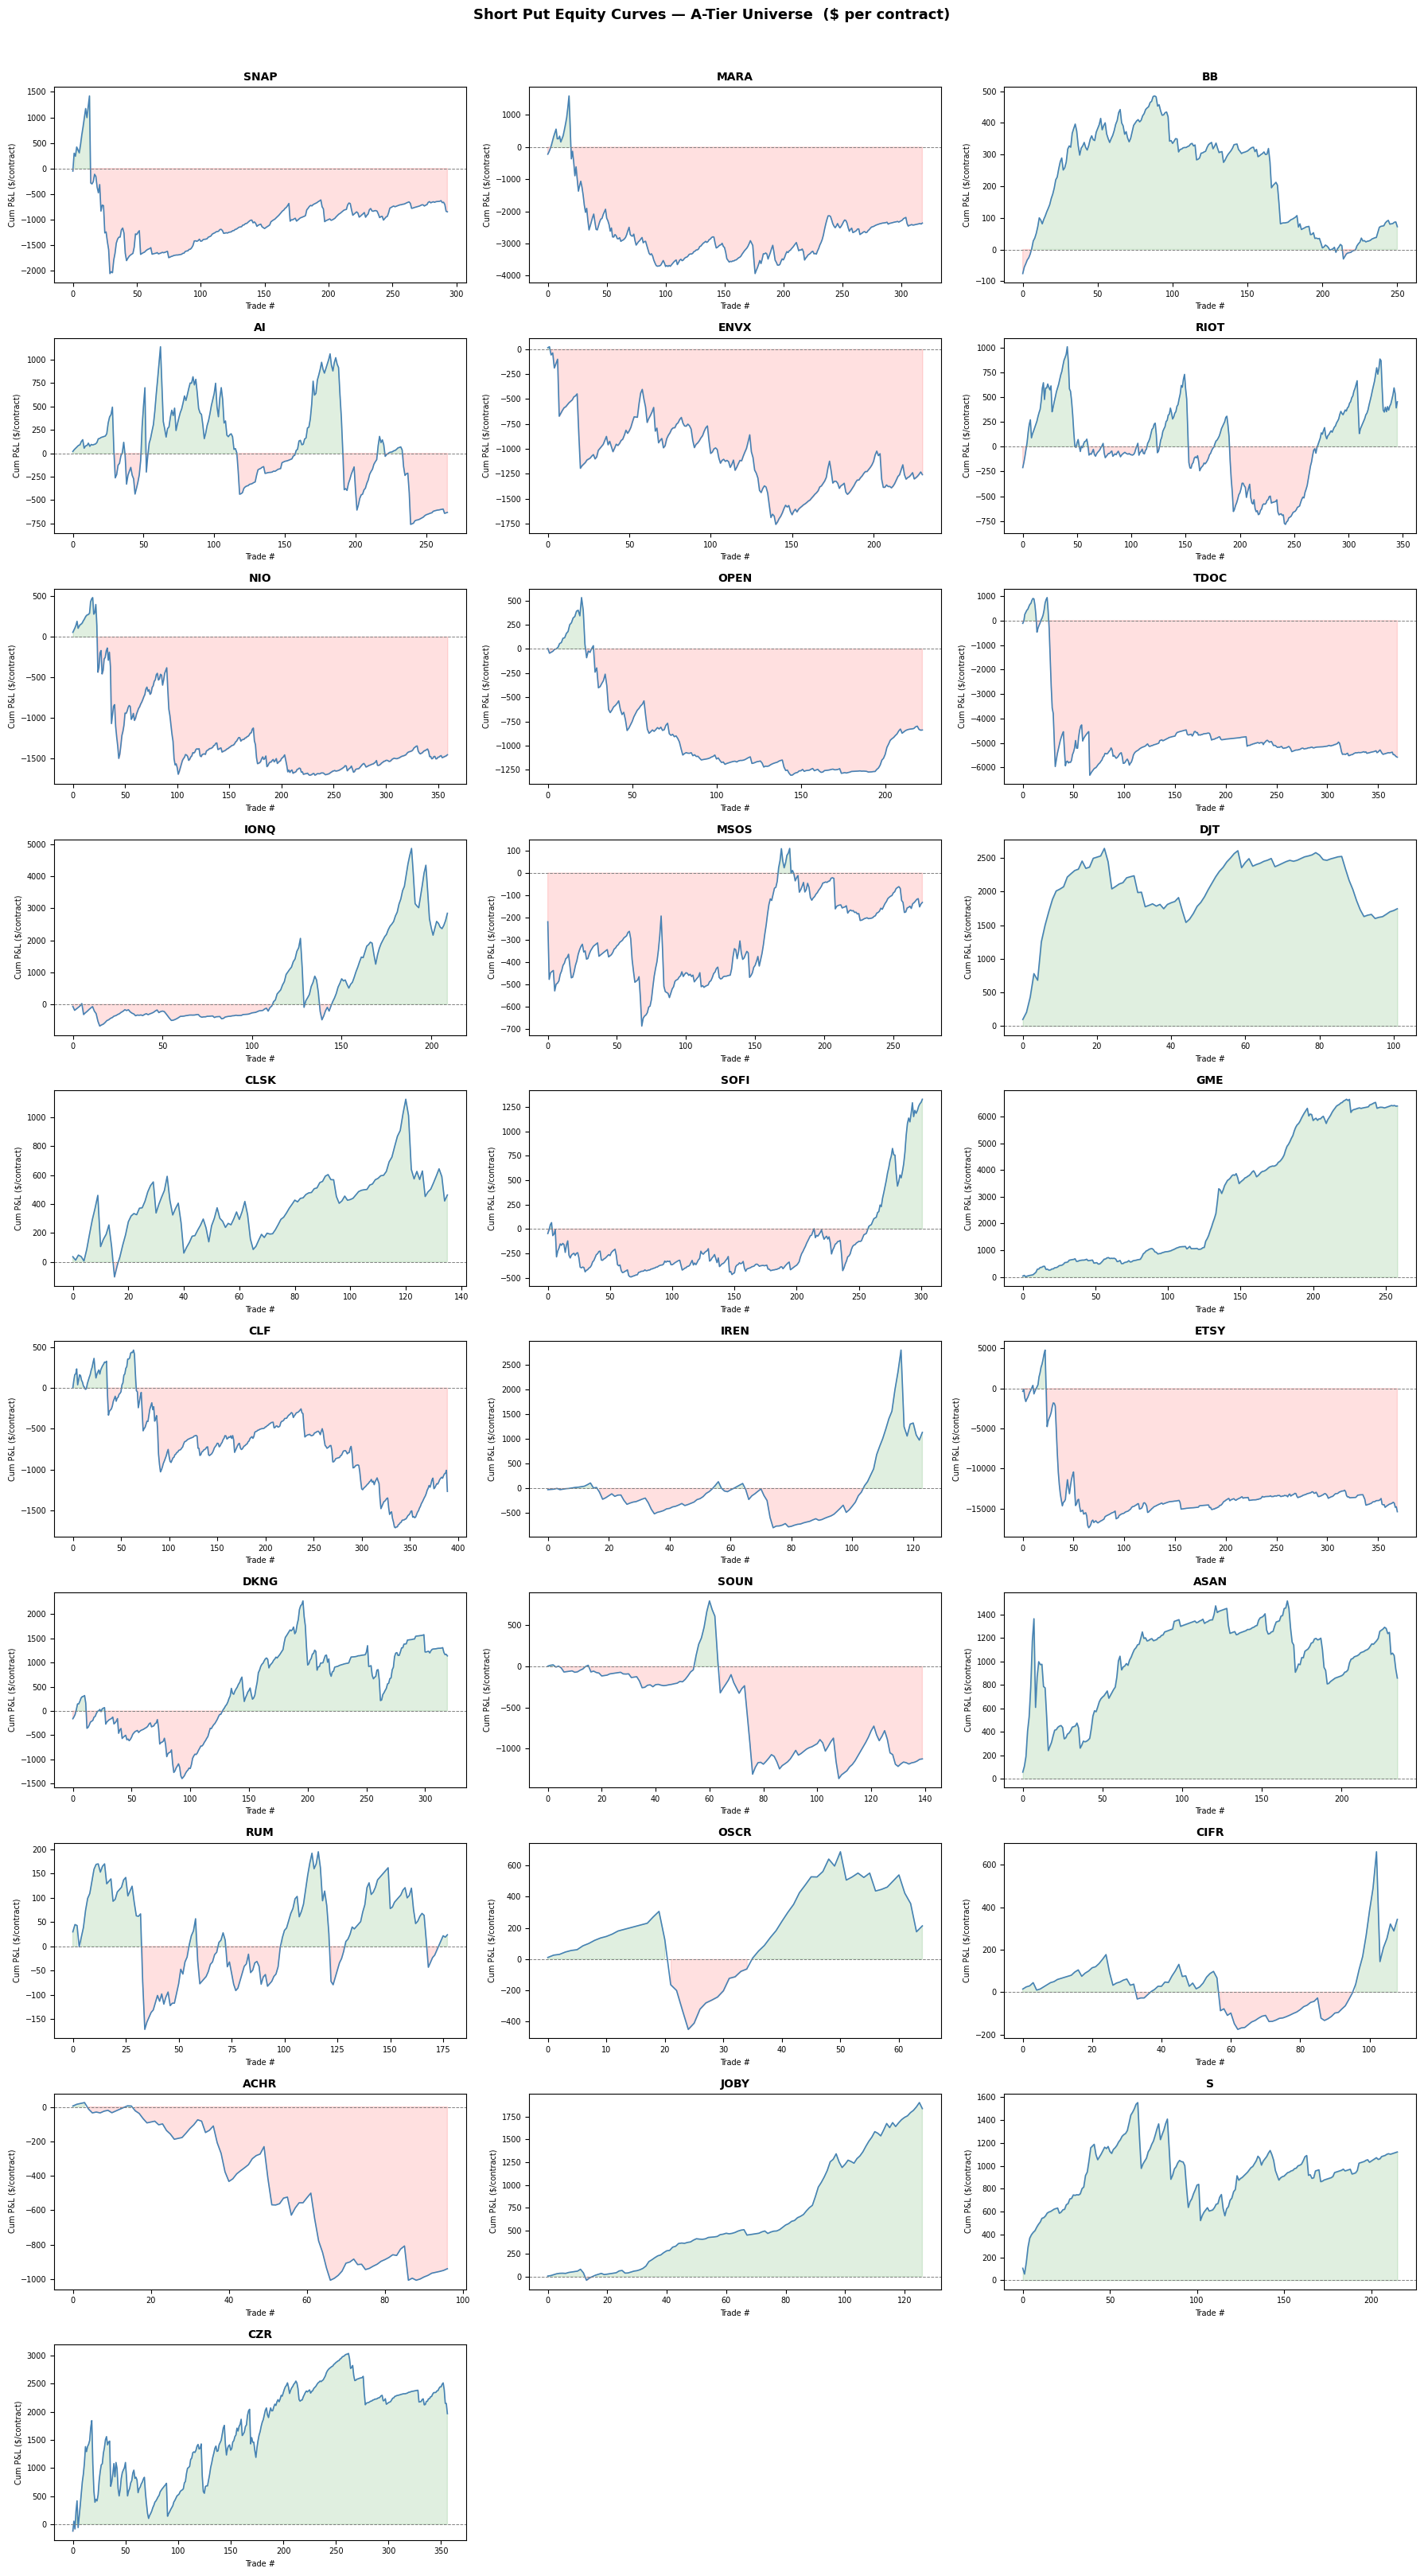

In [75]:
# ── Equity curves grid ────────────────────────────────────────────────────
tickers_with_trades = [
    t for t in universe
    if t in results and not results[t]['trades'].empty
    and 'pnl' in results[t]['trades'].columns
]

ncols = 3
nrows = max(1, (len(tickers_with_trades) + ncols - 1) // ncols)
cm    = CONTRACT_MULTIPLIER
DEDUP = ['quote_date', 'strike', 'expiration']

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3.2))
axes_flat = axes.flatten() if nrows > 1 else list(axes) if ncols == 1 else axes.flatten()

for i, ticker in enumerate(tickers_with_trades):
    ax = axes_flat[i]
    raw_trades = results[ticker]['trades']
    dcols  = [c for c in DEDUP if c in raw_trades.columns]
    trades = raw_trades.drop_duplicates(subset=dcols).sort_values('quote_date')
    pnl = trades['pnl'].dropna() * cm
    cum = pnl.cumsum().reset_index(drop=True)
    x   = np.arange(len(cum))

    ax.plot(cum.values, color='steelblue', linewidth=1.2)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.7)
    ax.fill_between(x, cum.values, 0, where=(cum.values >= 0), alpha=0.12, color='green')
    ax.fill_between(x, cum.values, 0, where=(cum.values < 0),  alpha=0.12, color='red')
    ax.set_title(ticker, fontsize=10, fontweight='bold')
    ax.set_xlabel('Trade #', fontsize=7)
    ax.set_ylabel('Cum P&L ($/contract)', fontsize=7)
    ax.tick_params(labelsize=7)

for j in range(len(tickers_with_trades), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle('Short Put Equity Curves — A-Tier Universe  ($ per contract)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


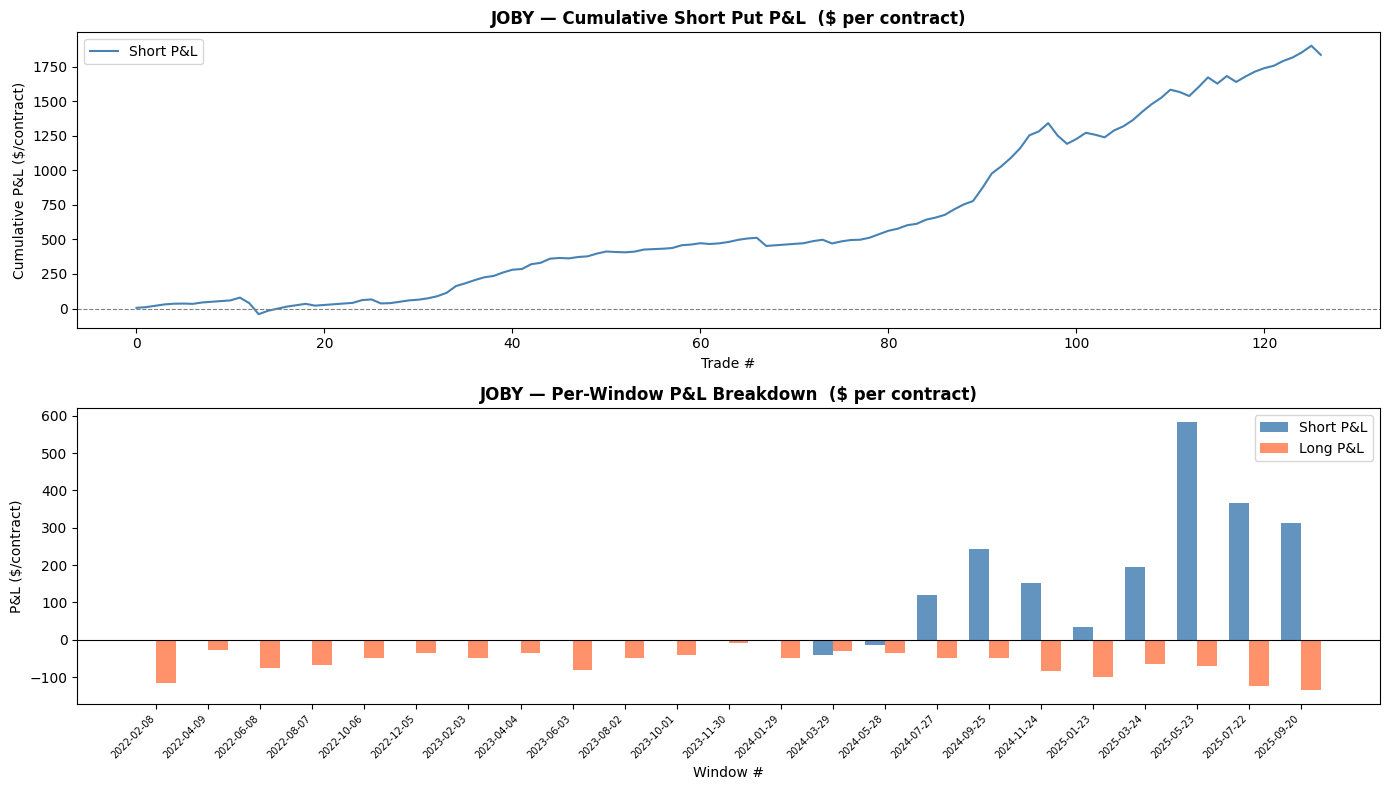

In [76]:
# ── Short vs long breakdown — best-Sharpe ticker ──────────────────────────
if metrics_df.empty:
    print('No metrics available.')
else:
    cm          = CONTRACT_MULTIPLIER
    DEDUP       = ['quote_date', 'strike', 'expiration']
    best_ticker = metrics_df.iloc[0]['ticker']
    res         = results[best_ticker]

    # Deduplicate trades (overlapping walk-forward windows)
    if not res['trades'].empty:
        dcols         = [c for c in DEDUP if c in res['trades'].columns]
        trades_sorted = res['trades'].drop_duplicates(subset=dcols).sort_values('quote_date')
    else:
        trades_sorted = pd.DataFrame()

    wins_sorted = res['windows'].sort_values('window_start') if not res['windows'].empty else pd.DataFrame()

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

    # Top: cumulative equity curve (per contract)
    if not trades_sorted.empty and 'pnl' in trades_sorted.columns:
        pnl = trades_sorted['pnl'].dropna() * cm
        cum = pnl.cumsum().reset_index(drop=True)
        ax1.plot(cum.values, color='steelblue', linewidth=1.5, label='Short P&L')
        ax1.axhline(0, color='gray', linestyle='--', linewidth=0.8)
        ax1.set_title(f'{best_ticker} — Cumulative Short Put P&L  ($ per contract)', fontsize=12, fontweight='bold')
        ax1.set_xlabel('Trade #')
        ax1.set_ylabel('Cumulative P&L ($/contract)')
        ax1.legend()

    # Bottom: per-window bar chart (short vs long, per contract)
    if not wins_sorted.empty and 'short_pnl' in wins_sorted.columns:
        x     = np.arange(len(wins_sorted))
        width = 0.38
        ax2.bar(x - width / 2, wins_sorted['short_pnl'].fillna(0) * cm, width,
                label='Short P&L', color='steelblue', alpha=0.85)
        if 'long_pnl' in wins_sorted.columns:
            ax2.bar(x + width / 2, wins_sorted['long_pnl'].fillna(0) * cm, width,
                    label='Long P&L', color='coral', alpha=0.85)
        ax2.axhline(0, color='black', linewidth=0.8)
        ax2.set_title(f'{best_ticker} — Per-Window P&L Breakdown  ($ per contract)', fontsize=12, fontweight='bold')
        ax2.set_xlabel('Window #')
        ax2.set_ylabel('P&L ($/contract)')
        ax2.legend()
        ax2.set_xticks(x)
        labels_x = [str(w)[:10] for w in wins_sorted['window_start']]
        ax2.set_xticklabels(labels_x, rotation=45, ha='right', fontsize=7)

    plt.tight_layout()
    plt.show()


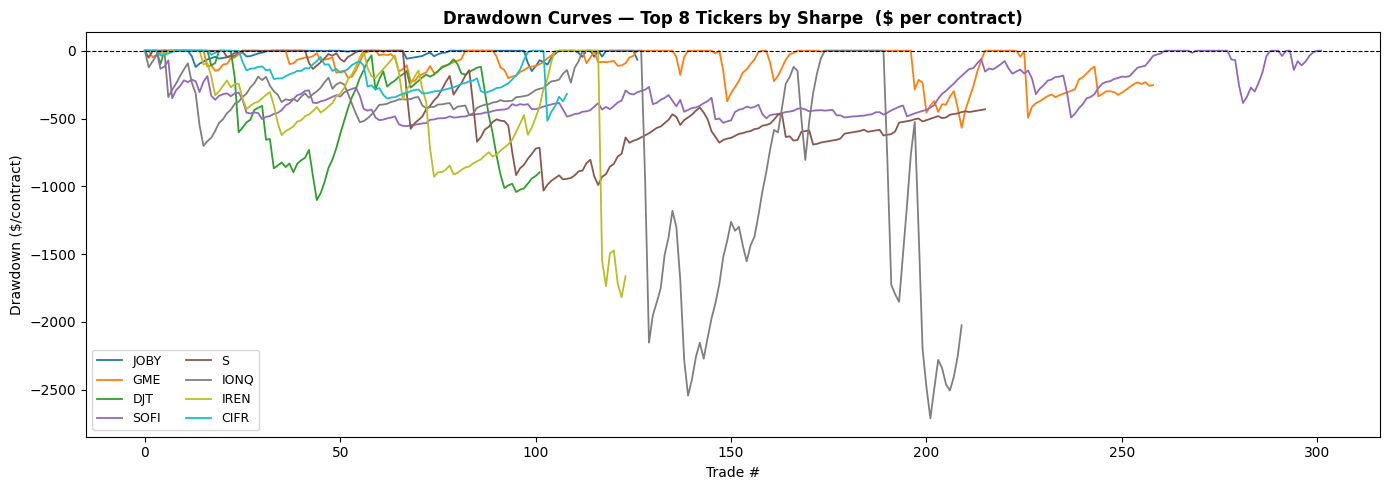

In [77]:
# ── Drawdown curves — top 8 tickers by Sharpe ─────────────────────────────
top8  = metrics_df.dropna(subset=['sharpe']).head(8)['ticker'].tolist()
cm    = CONTRACT_MULTIPLIER
DEDUP = ['quote_date', 'strike', 'expiration']

fig, ax = plt.subplots(figsize=(14, 5))
colors  = plt.cm.tab10(np.linspace(0, 1, len(top8)))

for ticker, color in zip(top8, colors):
    raw_trades = results[ticker]['trades']
    if raw_trades.empty or 'pnl' not in raw_trades.columns:
        continue
    dcols  = [c for c in DEDUP if c in raw_trades.columns]
    trades = raw_trades.drop_duplicates(subset=dcols).sort_values('quote_date')
    pnl    = trades['pnl'].dropna() * cm
    if len(pnl) < 2:
        continue
    cum      = pnl.cumsum().reset_index(drop=True)
    peak     = cum.cummax()
    drawdown = cum - peak
    ax.plot(drawdown.values, label=ticker, color=color, linewidth=1.3)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Drawdown Curves — Top 8 Tickers by Sharpe  ($ per contract)', fontsize=12, fontweight='bold')
ax.set_xlabel('Trade #')
ax.set_ylabel('Drawdown ($/contract)')
ax.legend(loc='lower left', ncol=2, fontsize=9)
plt.tight_layout()
plt.show()


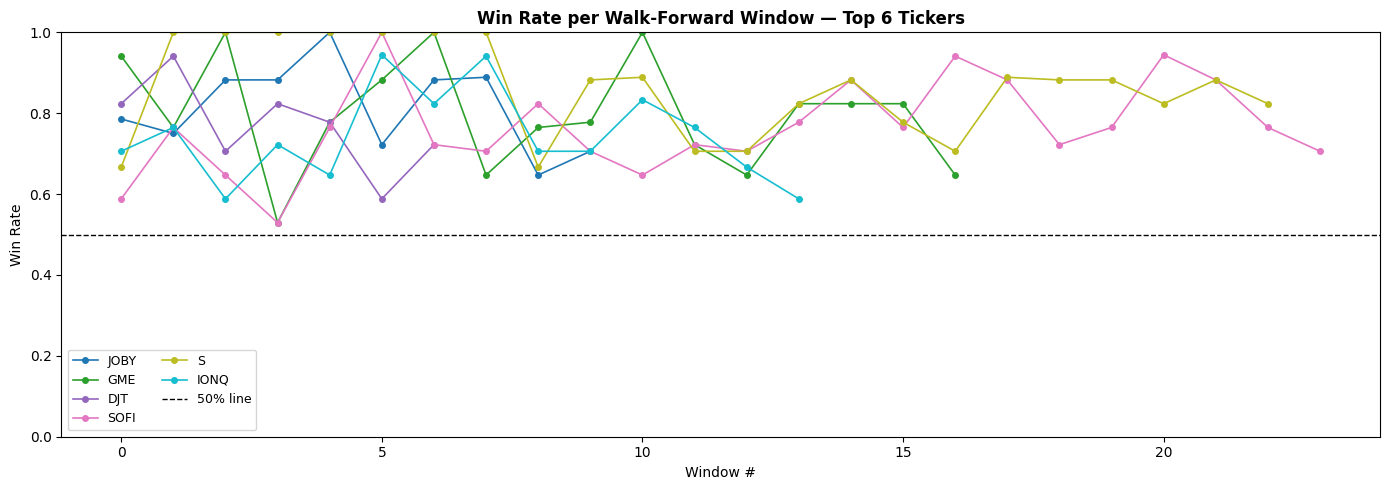

In [78]:
# ── Win rate over windows — top 6 tickers ─────────────────────────────────
top6 = metrics_df.dropna(subset=['sharpe']).head(6)['ticker'].tolist()

fig, ax = plt.subplots(figsize=(14, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(top6)))

for ticker, color in zip(top6, colors):
    res     = results[ticker]
    windows = res['windows']
    trades  = res['trades']
    if windows.empty or trades.empty or 'pnl' not in trades.columns:
        continue

    trades_cp = trades.copy()
    trades_cp['window_start'] = pd.to_datetime(trades_cp['window_start'])

    win_rates = []
    for _, win_row in windows.iterrows():
        ws = pd.to_datetime(win_row['window_start'])
        w_trades = trades_cp[trades_cp['window_start'] == ws]
        if len(w_trades) > 0:
            win_rates.append(float((w_trades['pnl'] > 0).mean()))
        else:
            win_rates.append(np.nan)

    wr_series = pd.Series(win_rates).dropna()
    if not wr_series.empty:
        ax.plot(wr_series.values, label=ticker, color=color,
                linewidth=1.2, marker='o', markersize=4)

ax.axhline(0.5, color='black', linestyle='--', linewidth=1.0, label='50% line')
ax.set_ylim(0, 1)
ax.set_title('Win Rate per Walk-Forward Window — Top 6 Tickers', fontsize=12, fontweight='bold')
ax.set_xlabel('Window #')
ax.set_ylabel('Win Rate')
ax.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

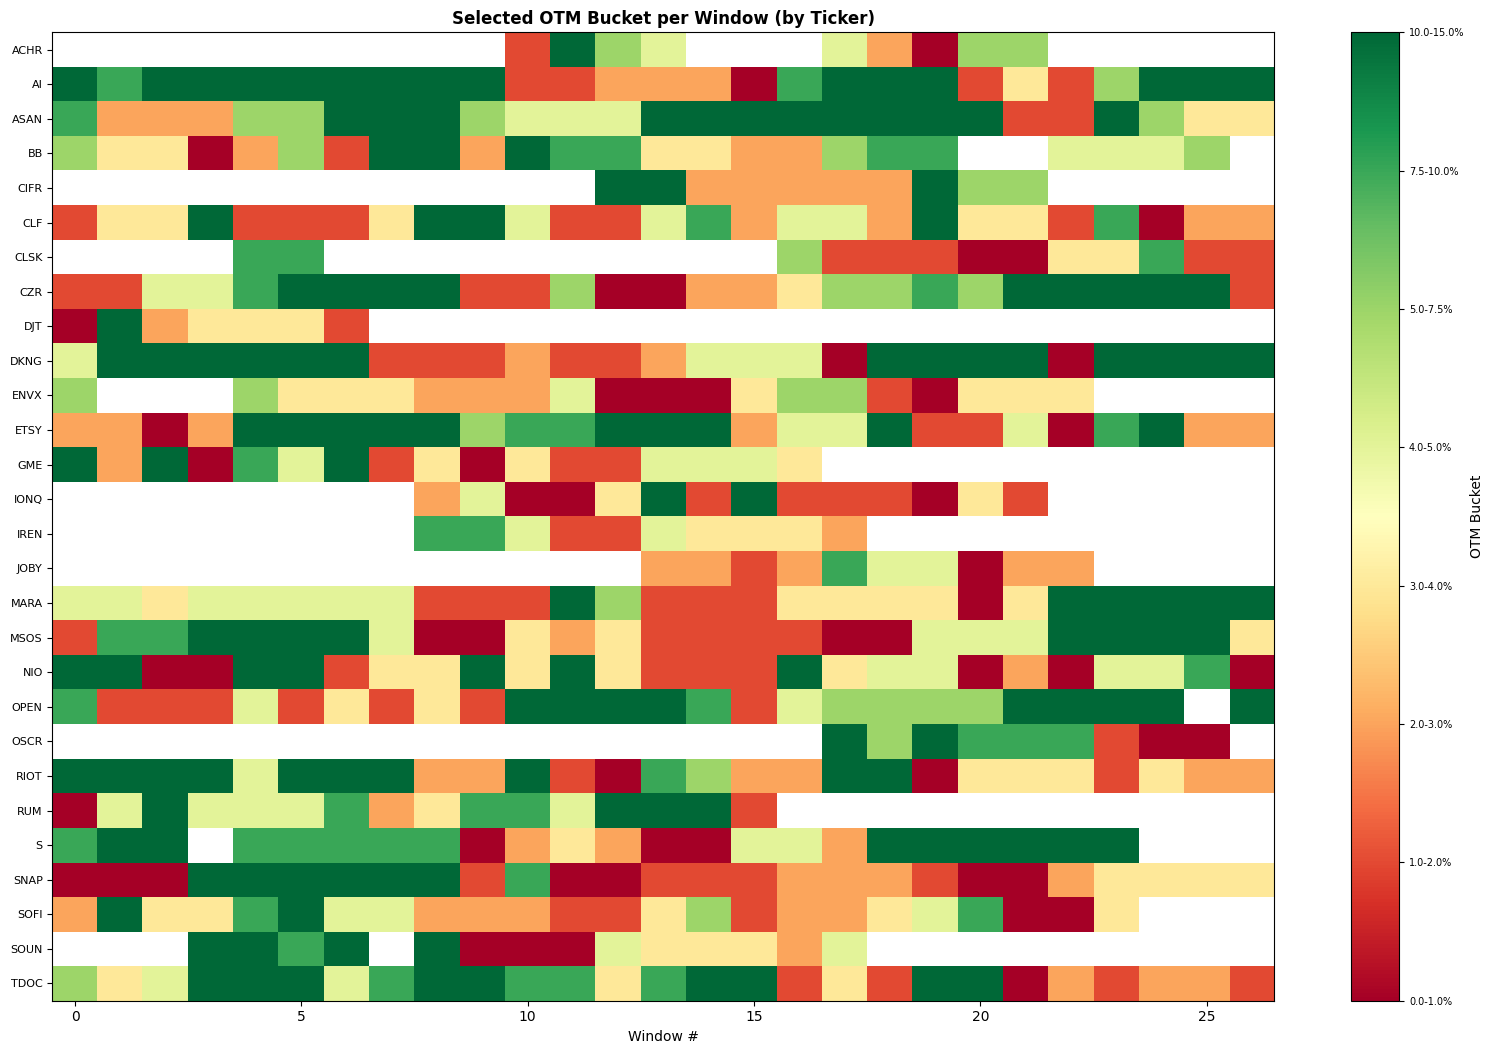

In [79]:
# ── Bucket stability heatmap ───────────────────────────────────────────────
if not all_windows_df.empty and 'target_bucket' in all_windows_df.columns:
    wdf = all_windows_df.copy()
    wdf['window_idx']  = wdf.groupby('ticker').cumcount()
    label_to_idx       = {lbl: i for i, lbl in enumerate(OTM_LABELS)}
    wdf['bucket_idx']  = wdf['target_bucket'].map(label_to_idx)

    pivot = wdf.pivot_table(
        index='ticker', columns='window_idx',
        values='bucket_idx', aggfunc='first'
    )

    h = max(6, len(pivot) * 0.38)
    fig, ax = plt.subplots(figsize=(16, h))
    im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn',
                   vmin=0, vmax=len(OTM_LABELS) - 1)

    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=8)
    ax.set_xlabel('Window #')
    ax.set_title('Selected OTM Bucket per Window (by Ticker)', fontsize=12, fontweight='bold')

    cbar = plt.colorbar(im, ax=ax, ticks=range(len(OTM_LABELS)))
    cbar.ax.set_yticklabels(OTM_LABELS, fontsize=7)
    cbar.set_label('OTM Bucket')

    plt.tight_layout()
    plt.show()
else:
    print('No window data for heatmap.')

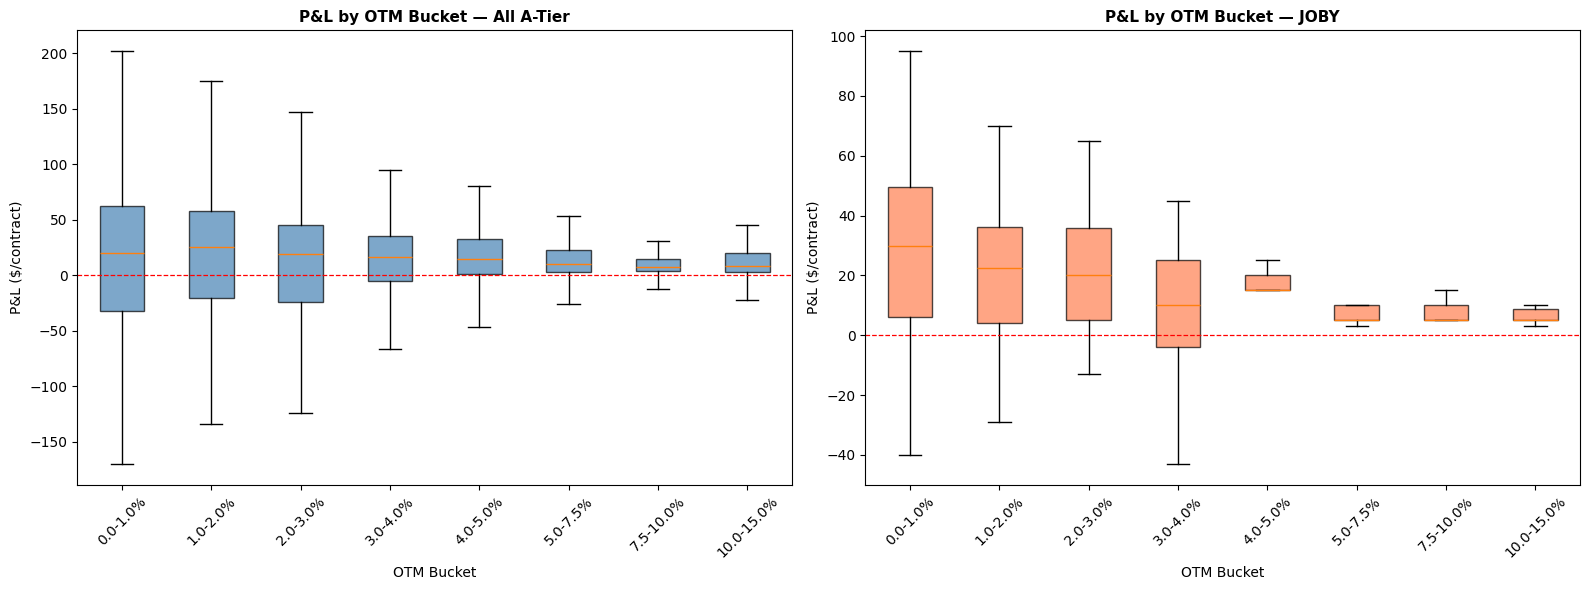

In [80]:
# ── P&L box plots by OTM bucket ───────────────────────────────────────────
if all_trades_df.empty or 'otm_bucket' not in all_trades_df.columns:
    print('No trade data for box plots.')
else:
    cm   = CONTRACT_MULTIPLIER
    atdf = all_trades_df.copy()
    atdf['bucket_str'] = atdf['otm_bucket'].astype(str)

    best_sharpe_ticker = metrics_df.iloc[0]['ticker'] if not metrics_df.empty else None

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # All tickers combined
    present_buckets = [b for b in OTM_LABELS if b in atdf['bucket_str'].values]
    data_all = [atdf[atdf['bucket_str'] == b]['pnl'].dropna().values * cm for b in present_buckets]
    ax1.boxplot(data_all, labels=present_buckets, showfliers=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
    ax1.axhline(0, color='red', linestyle='--', linewidth=0.9)
    ax1.set_title('P&L by OTM Bucket — All A-Tier', fontsize=11, fontweight='bold')
    ax1.set_xlabel('OTM Bucket')
    ax1.set_ylabel('P&L ($/contract)')
    ax1.tick_params(axis='x', rotation=45)

    # Best Sharpe ticker
    if best_sharpe_ticker and best_sharpe_ticker in atdf['ticker'].values:
        best_df  = atdf[atdf['ticker'] == best_sharpe_ticker]
        present2 = [b for b in OTM_LABELS if b in best_df['bucket_str'].values]
        data2    = [best_df[best_df['bucket_str'] == b]['pnl'].dropna().values * cm for b in present2]
        ax2.boxplot(data2, labels=present2, showfliers=False, patch_artist=True,
                    boxprops=dict(facecolor='coral', alpha=0.7))
        ax2.axhline(0, color='red', linestyle='--', linewidth=0.9)
        ax2.set_title(f'P&L by OTM Bucket — {best_sharpe_ticker}', fontsize=11, fontweight='bold')
        ax2.set_xlabel('OTM Bucket')
        ax2.set_ylabel('P&L ($/contract)')
        ax2.tick_params(axis='x', rotation=45)
    else:
        ax2.set_visible(False)

    plt.tight_layout()
    plt.show()


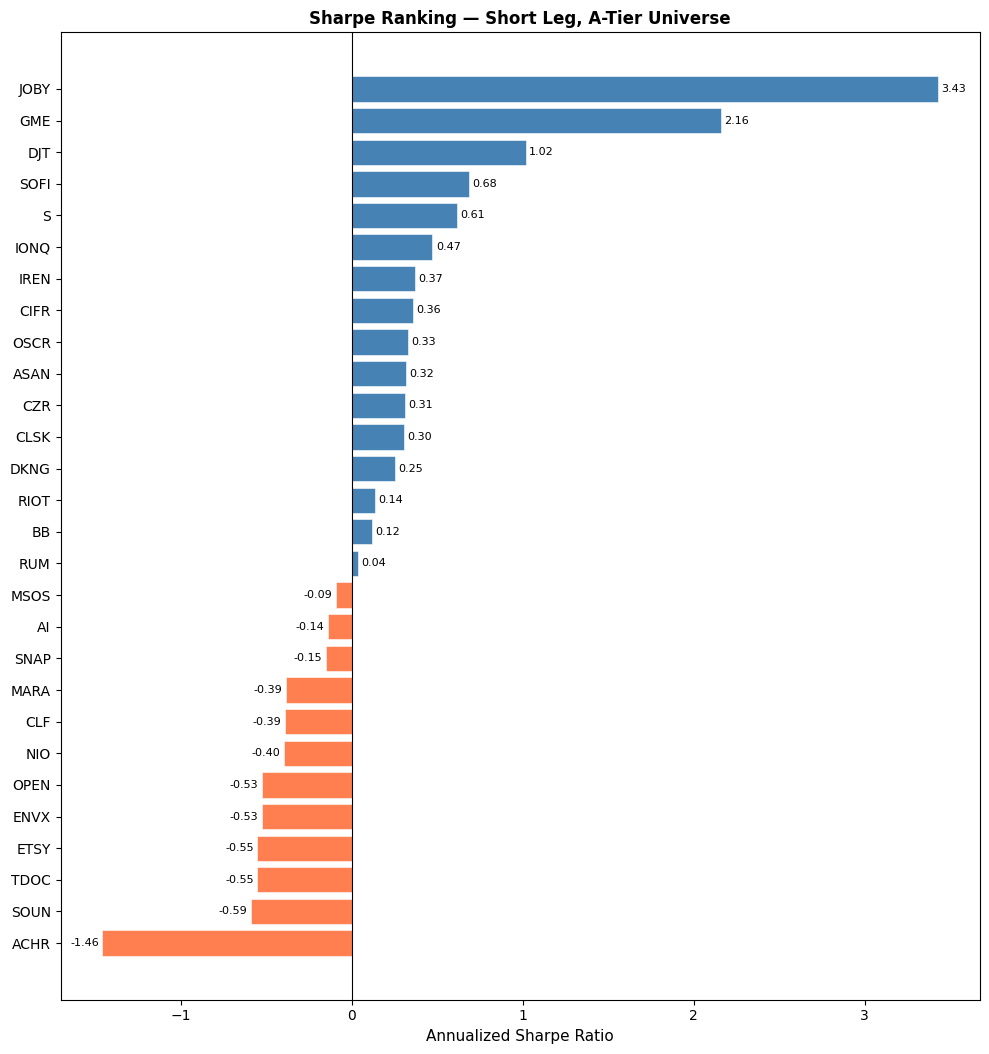

In [81]:
# ── Sharpe ranking bar chart ──────────────────────────────────────────────
if metrics_df.empty:
    print('No metrics to plot.')
else:
    sdf = metrics_df.dropna(subset=['sharpe']).sort_values('sharpe', ascending=True)
    colors = ['coral' if s < 0 else 'steelblue' for s in sdf['sharpe']]

    fig, ax = plt.subplots(figsize=(10, max(6, len(sdf) * 0.38)))
    bars = ax.barh(sdf['ticker'], sdf['sharpe'], color=colors, edgecolor='white', linewidth=0.4)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Annualized Sharpe Ratio', fontsize=11)
    ax.set_title('Sharpe Ranking — Short Leg, A-Tier Universe', fontsize=12, fontweight='bold')

    for bar, val in zip(bars, sdf['sharpe']):
        offset = 0.02 if val >= 0 else -0.02
        ha     = 'left' if val >= 0 else 'right'
        ax.text(val + offset, bar.get_y() + bar.get_height() / 2,
                f'{val:.2f}', va='center', ha=ha, fontsize=8)

    plt.tight_layout()
    plt.show()

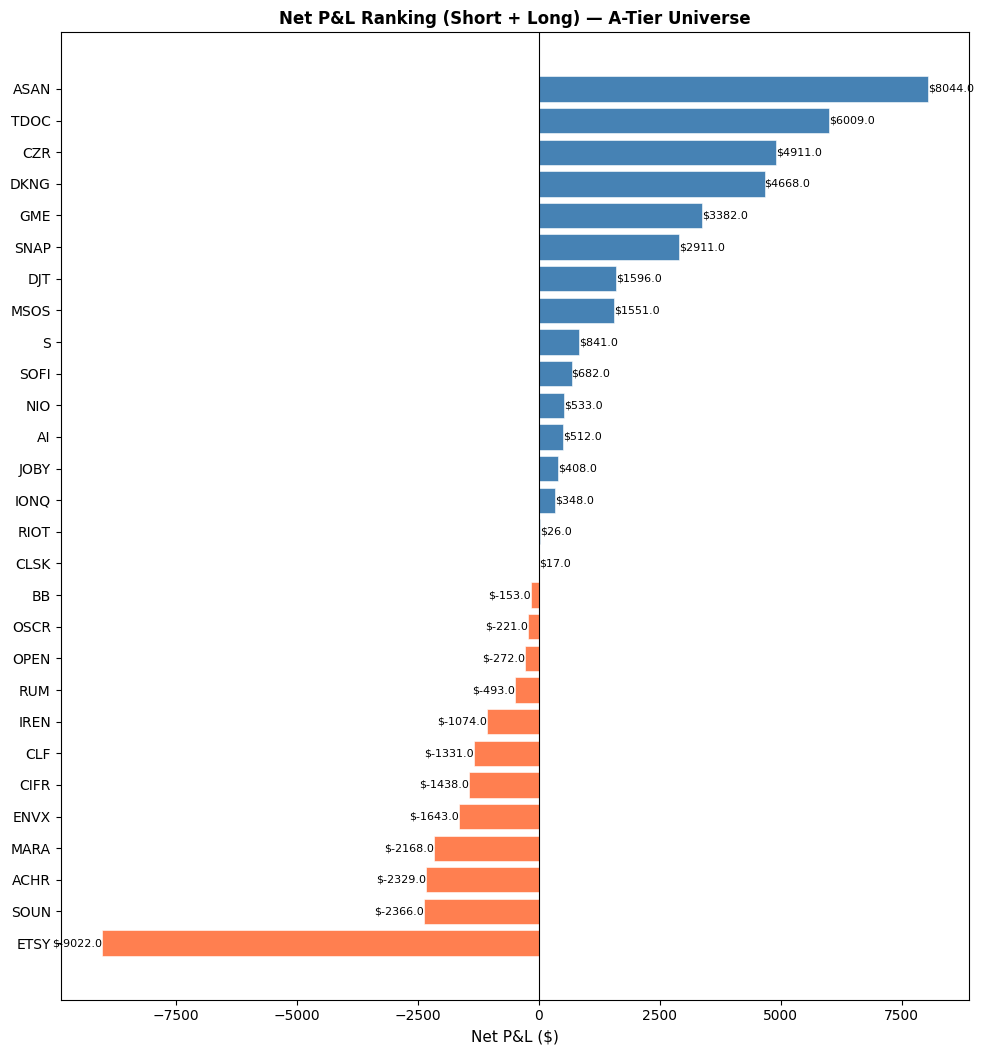

In [82]:
# ── Net P&L ranking bar chart ─────────────────────────────────────────────
if metrics_df.empty:
    print('No metrics to plot.')
else:
    ndf    = metrics_df.sort_values('net_pnl', ascending=True)
    colors = ['coral' if v < 0 else 'steelblue' for v in ndf['net_pnl']]

    fig, ax = plt.subplots(figsize=(10, max(6, len(ndf) * 0.38)))
    bars = ax.barh(ndf['ticker'], ndf['net_pnl'], color=colors,
                   edgecolor='white', linewidth=0.4)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Net P&L ($)', fontsize=11)
    ax.set_title('Net P&L Ranking (Short + Long) — A-Tier Universe', fontsize=12, fontweight='bold')

    for bar, val in zip(bars, ndf['net_pnl']):
        offset = 0.5 if val >= 0 else -0.5
        ha     = 'left' if val >= 0 else 'right'
        ax.text(val + offset, bar.get_y() + bar.get_height() / 2,
                f'${val:.1f}', va='center', ha=ha, fontsize=8)

    plt.tight_layout()
    plt.show()

---
## Section 6 — Results Summary

The cells below produce three outputs:

1. **Aggregate summary** (`cell-19`): Headline numbers — total trades, overall win rate, average weekly premium collected, total short/long/net P&L across all tickers
2. **Data quality report** (`cell-20`): Per-ticker breakdown of windows, trades, long puts, and fallback rates — flag any tickers with data issues
3. **Strategy analysis** (`cell-21`): Which ticker, OTM bucket, and entry day performed best; how many tickers were net profitable; most-selected bucket per selection method

> **Reading the results**: Net P&L > 0 per contract = the full strategy (both legs) was profitable over the backtest period. Focus on tickers combining positive net P&L, Sharpe > 0.5, and fallback rate < 30%.


In [83]:
# ── Printed summary block ─────────────────────────────────────────────────
if metrics_df.empty or all_trades_df.empty:
    print('No data for summary.')
else:
    cm             = CONTRACT_MULTIPLIER
    overall_wr     = float((all_trades_df['pnl'] > 0).mean()) if 'pnl' in all_trades_df.columns else np.nan
    total_short    = float(metrics_df['total_short_pnl'].sum())   # already scaled
    total_long     = float(metrics_df['total_long_pnl'].sum())    # already scaled
    net_all        = float(metrics_df['net_pnl'].sum())           # already scaled
    avg_premium    = float(all_trades_df['bid'].mean()) * cm if 'bid' in all_trades_df.columns else np.nan
    n_windows_all  = len(all_windows_df) if not all_windows_df.empty else 0
    entry_label    = 'Thu+Fri' if ENTRY_DOW is None else ('Thu' if ENTRY_DOW == 3 else 'Fri')

    print('=' * 62)
    print('  KaChing Walk-Forward Backtest  --  Summary')
    print(f'  (All P&L = $ per contract, {cm}x multiplier applied)')
    print('=' * 62)
    print(f'  Universe         : {TIER_FILTER}-tier | {len(universe)} tickers')
    print(f'  Walk-forward     : train={TRAIN_DAYS}d / test={TEST_DAYS}d / step={STEP_DAYS}d')
    print(f'  Selection method : {SELECTION_METHOD}')
    print(f'  Entry DOW        : {entry_label}')
    print()
    print(f'  Total windows    : {n_windows_all}')
    print(f'  Total trades     : {len(all_trades_df):,}')
    print(f'  Overall win rate : {overall_wr:.1%}')
    print(f'  Avg weekly premium: ${avg_premium:.2f} / contract')
    print()
    print(f'  Total short P&L  : ${total_short:,.2f}')
    print(f'  Total long  P&L  : ${total_long:,.2f}')
    print(f'  Net P&L (all)    : ${net_all:,.2f}')
    print()
    print('  Top 5 by Sharpe:')
    for _, row in metrics_df.dropna(subset=['sharpe']).head(5).iterrows():
        print(f"    {row['ticker']:<6s}  Sharpe={row['sharpe']:+.2f}  "
              f"WR={row['win_rate']:.1%}  Net=${row['net_pnl']:,.0f}")
    print('=' * 62)

  KaChing Walk-Forward Backtest  --  Summary
  (All P&L = $ per contract, 100x multiplier applied)
  Universe         : A-tier | 29 tickers
  Walk-forward     : train=180d / test=120d / step=60d
  Selection method : composite
  Entry DOW        : Thu+Fri

  Total windows    : 666
  Total trades     : 6,678
  Overall win rate : 76.1%
  Avg weekly premium: $45.81 / contract

  Total short P&L  : $-9,889.00
  Total long  P&L  : $23,818.00
  Net P&L (all)    : $13,929.00

  Top 5 by Sharpe:
    JOBY    Sharpe=+3.43  WR=84.3%  Net=$408
    GME     Sharpe=+2.16  WR=82.2%  Net=$3,382
    DJT     Sharpe=+1.02  WR=76.5%  Net=$1,596
    SOFI    Sharpe=+0.68  WR=76.2%  Net=$682
    S       Sharpe=+0.61  WR=81.9%  Net=$841


In [84]:
# ── Data quality report ───────────────────────────────────────────────────
print('=' * 62)
print('  Data Quality Report')
print('=' * 62)

for ticker in universe:
    res = results.get(ticker)
    if res is None:
        err_msg = errors.get(ticker, 'unknown error')
        print(f'  {ticker:<6s}  FAILED  ({err_msg[:60]})')
        continue

    n_trades  = len(res['trades'])    if not res['trades'].empty    else 0
    n_long    = len(res['long_puts']) if not res['long_puts'].empty else 0
    n_windows = len(res['windows'])   if not res['windows'].empty   else 0

    fallback_str = ''
    if not res['windows'].empty and 'n_trades' in res['windows'].columns:
        total_t = res['windows']['n_trades'].sum()
        total_f = res['windows']['fallback_count'].sum() if 'fallback_count' in res['windows'].columns else 0
        fr = total_f / total_t if total_t > 0 else 0.0
        fallback_str = f'  fallback={fr:.1%}'

    long_warn = '  [!] no long puts' if n_long == 0 else ''

    print(f'  {ticker:<6s}  windows={n_windows:3d}  trades={n_trades:4d}  '
          f'long_puts={n_long:3d}{fallback_str}{long_warn}')

print('=' * 62)

  Data Quality Report
  SNAP    windows= 27  trades= 466  long_puts= 27  fallback=43.8%
  MARA    windows= 27  trades= 464  long_puts= 27  fallback=40.3%
  BB      windows= 26  trades= 349  long_puts= 26  fallback=70.8%
  AI      windows= 27  trades= 356  long_puts= 27  fallback=15.7%
  ENVX    windows= 23  trades= 332  long_puts= 23  fallback=59.6%
  RIOT    windows= 27  trades= 466  long_puts= 27  fallback=38.6%
  NIO     windows= 27  trades= 456  long_puts= 27  fallback=53.9%
  OPEN    windows= 27  trades= 332  long_puts= 27  fallback=69.3%
  TDOC    windows= 27  trades= 466  long_puts= 27  fallback=25.1%
  IONQ    windows= 22  trades= 242  long_puts= 22  fallback=33.9%
  MSOS    windows= 27  trades= 425  long_puts= 27  fallback=59.1%
  DJT     windows=  7  trades= 121  long_puts=  7  fallback=39.7%
  CLSK    windows= 27  trades= 195  long_puts= 27  fallback=48.7%
  SOFI    windows= 24  trades= 413  long_puts= 24  fallback=54.2%
  GME     windows= 17  trades= 293  long_puts= 17  fal

In [85]:
# ── Strategy analysis — what worked best ─────────────────────────────────
if metrics_df.empty or all_trades_df.empty:
    print('No data for strategy analysis.')
else:
    cm = CONTRACT_MULTIPLIER

    # Best ticker by each dimension
    mdf_sharpe = metrics_df.dropna(subset=['sharpe'])
    best_sharpe = mdf_sharpe.iloc[0] if not mdf_sharpe.empty else None
    best_net    = metrics_df.sort_values('net_pnl', ascending=False).iloc[0]
    best_wr     = metrics_df.sort_values('win_rate', ascending=False).iloc[0]

    # Best OTM bucket overall (all tickers combined, min 20 trades)
    best_bucket_row = None
    if 'otm_bucket' in all_trades_df.columns:
        atdf = all_trades_df.copy()
        atdf['bucket_str'] = atdf['otm_bucket'].astype(str)
        bstats = (
            atdf.groupby('bucket_str')['pnl']
            .agg(n='count', mean_pnl='mean', win_rate=lambda x: (x > 0).mean())
            .reset_index()
        )
        bstats = bstats[bstats['n'] >= 20]
        if not bstats.empty:
            best_bucket_row = bstats.loc[bstats['mean_pnl'].idxmax()]

    # Thu vs Fri winner (from comparison_df built in cell-10)
    dow_winner = None
    try:
        if not comparison_df.empty:
            dow_pnl    = comparison_df.groupby('entry_day')['total_pnl'].sum()
            dow_winner = dow_pnl.idxmax() if not dow_pnl.empty else None
    except NameError:
        pass

    # Most-selected bucket per selection method
    method_cols = [c for c in ['best_ev', 'best_winrate', 'best_sharpe', 'best_composite']
                   if not all_windows_df.empty and c in all_windows_df.columns]

    # Profitable vs unprofitable split
    pos = metrics_df[metrics_df['net_pnl'] > 0].sort_values('net_pnl', ascending=False)
    neg = metrics_df[metrics_df['net_pnl'] <= 0].sort_values('net_pnl')

    print('=' * 66)
    print('  STRATEGY ANALYSIS — What Worked Best')
    print('=' * 66)
    print()
    print('  ── Best tickers ──────────────────────────────────────────────')
    if best_sharpe is not None:
        print(f"  By Sharpe   : {best_sharpe['ticker']:<6s}  "
              f"Sharpe={best_sharpe['sharpe']:+.2f}  "
              f"WR={best_sharpe['win_rate']:.1%}  "
              f"Net=${best_sharpe['net_pnl']:,.0f}")
    print(f"  By Net P&L  : {best_net['ticker']:<6s}  "
          f"Net=${best_net['net_pnl']:,.0f}  "
          f"Sharpe={best_net['sharpe']:+.2f}")
    print(f"  By Win Rate : {best_wr['ticker']:<6s}  "
          f"WR={best_wr['win_rate']:.1%}  "
          f"Net=${best_wr['net_pnl']:,.0f}")
    print()

    if best_bucket_row is not None:
        print('  ── Best OTM bucket (all tickers combined) ────────────────────')
        print(f"  Bucket      : {best_bucket_row['bucket_str']}  "
              f"  n={int(best_bucket_row['n'])}  "
              f"  avg=${best_bucket_row['mean_pnl'] * cm:.2f}/contract  "
              f"  WR={best_bucket_row['win_rate']:.1%}")
        print()

    if dow_winner:
        print('  ── Entry day ─────────────────────────────────────────────────')
        print(f"  Better day  : {dow_winner} entry (higher total P&L across first 5 tickers)")
        print()

    if method_cols:
        print('  ── Most-selected bucket per method ───────────────────────────')
        for mc in method_cols:
            series = all_windows_df[mc].dropna()
            if not series.empty:
                top = series.value_counts().index[0]
                pct = series.value_counts().iloc[0] / len(series)
                print(f"  {mc:<22s}: {top}  ({pct:.0%} of windows)")
        print()

    print('  ── Universe profitability ────────────────────────────────────')
    print(f"  Profitable  ({len(pos)}/{len(metrics_df)}): "
          f"{', '.join(pos['ticker'].tolist()[:10])}{'...' if len(pos) > 10 else ''}")
    if not neg.empty:
        print(f"  Unprofitable ({len(neg)}/{len(metrics_df)}): "
              f"{', '.join(neg['ticker'].tolist())}")
    print()

    print('  ── Top 5 recommended tickers ─────────────────────────────────')
    recommended = metrics_df[
        (metrics_df['net_pnl'] > 0) &
        (metrics_df['sharpe'] > 0.5) &
        (metrics_df['fallback_rate'].fillna(1) < 0.30)
    ].head(5)
    if recommended.empty:
        # Relax criteria if nothing matches
        recommended = metrics_df[metrics_df['net_pnl'] > 0].head(5)
    for _, row in recommended.iterrows():
        fr = f"  fallback={row['fallback_rate']:.0%}" if not pd.isna(row['fallback_rate']) else ''
        print(f"    {row['ticker']:<6s}  Sharpe={row['sharpe']:+.2f}  "
              f"WR={row['win_rate']:.1%}  Net=${row['net_pnl']:,.0f}{fr}")
    print('=' * 66)


  STRATEGY ANALYSIS — What Worked Best

  ── Best tickers ──────────────────────────────────────────────
  By Sharpe   : JOBY    Sharpe=+3.43  WR=84.3%  Net=$408
  By Net P&L  : ASAN    Net=$8,044  Sharpe=+0.32
  By Win Rate : JOBY    WR=84.3%  Net=$408

  ── Best OTM bucket (all tickers combined) ────────────────────
  Bucket      : 1.0-2.0%    n=775    avg=$5.91/contract    WR=67.7%

  ── Entry day ─────────────────────────────────────────────────
  Better day  : Fri entry (higher total P&L across first 5 tickers)

  ── Most-selected bucket per method ───────────────────────────
  best_ev               : 10.0-15.0%  (20% of windows)
  best_winrate          : 10.0-15.0%  (69% of windows)
  best_sharpe           : 10.0-15.0%  (36% of windows)
  best_composite        : 10.0-15.0%  (27% of windows)

  ── Universe profitability ────────────────────────────────────
  Profitable  (16/28): ASAN, TDOC, CZR, DKNG, GME, SNAP, DJT, MSOS, S, SOFI...
  Unprofitable (12/28): ETSY, SOUN, ACHR, MARA,

---

## Conclusion & Next Steps

### How to Read the Results

The **Recommended Tickers** block above applies three filters — net profitable, Sharpe > 0.5, fallback rate < 30% — to identify tickers where all three conditions for a workable strategy are met simultaneously. Use these as your primary candidates for paper trading.

### Interpreting Key Metrics

| Result | Meaning | Action |
|---|---|---|
| Net P&L > 0, Sharpe > 0.5 | Strategy works on this ticker | Add to active watchlist |
| Net P&L > 0, Sharpe < 0 | Profitable but very inconsistent | Trade cautiously, monitor |
| Net P&L < 0, Sharpe < 0 | Strategy loses money here | Exclude or skip |
| Fallback rate > 30% | Target bucket unavailable too often | Consider a wider bucket or exclude |
| Long P&L strongly negative | Hedge cost > benefit | Try sizing down the long leg |

### Important Caveats

1. **No execution costs**: Bid/ask spreads at execution, commissions, and slippage are not modeled. Real performance will be lower — estimate 5–15% haircut on premium collected.
2. **One contract**: All P&L figures are per single contract (100 shares). Scale by position size for portfolio-level numbers.
3. **Survivorship bias**: The universe consists of tickers that are currently A-tier, which already have favorable options characteristics. Some may have reached A-tier *because* they performed well historically.
4. **Regime sensitivity**: Short put strategies suffer in sharp-decline markets. Review per-window equity curves (cell-11) for drawdown periods — if losses cluster in 2022 or early 2020, add regime filters before going live.
5. **Walk-forward is not a guarantee**: The train/test split prevents in-sample overfitting, but the bucket selection model is simple. More windows = more reliable signal; tickers with fewer than 5 windows should be treated with caution.

### Suggested Next Steps

- [ ] Paper trade the top 3 recommended tickers for 8 weeks before committing capital
- [ ] Re-run with `SELECTION_METHOD = 'ev'` and `'winrate'` to compare against composite
- [ ] Run `ENTRY_DOW = 4` (Friday only) if the Thu/Fri comparison shows Friday dominates
- [ ] Download fresher data and re-run to validate the strategy holds out-of-sample
- [ ] Consider adding a VIX regime filter: only sell puts when VIX > 18 (higher premium)
